In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import plotly.io as pio
import plotly.graph_objects as go
import os

In [27]:
# Путь к файлам
mode = 'FR0'

#lattice = 'magnetic_2p'
#lattice = 'magnetic_sextupoles'
lattice = 'magnetic_mod'
#lattice = 'electrostatic'
#lattice = 'Nuclotron_16'
#lattice = 'Nuclotron_8'

base_path = f'C:/GIT_REPOS/SCT/COSY/src/dat/{lattice}'

file_integrals = f'{base_path}/integrals_{mode}.dat'
file_spin_tune = f'{base_path}/particle_spin_tune_{mode}.dat'
file_spin_tune_1 = f'{base_path}/particle_spin_tune_1_{mode}.dat'

In [28]:
# Определение колонок
cols_int = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'chrom_x', 'chrom_y', 'MU_ref', 'quad_Kx', 'quad_Ky', 'quad_Kz', 'alpha_0', 'alpha_1', 'eta_1']
cols_spin = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'spin_ref', 'spin_x', 'spin_y', 'spin_z']
cols_spin_1 = ['SGx1', 'SGx2', 'SGy1', 'SGy2', 'spin_ref_1', 'spin_x_1', 'spin_y_1', 'spin_z_1']

# 1. Чтение основных данных
df_int = pd.read_csv(file_integrals, sep=r'\s+', names=cols_int, engine='python')
df_spin = pd.read_csv(file_spin_tune, sep=r'\s+', names=cols_spin, engine='python')
df_spin_1 = pd.read_csv(file_spin_tune_1, sep=r'\s+', names=cols_spin_1, engine='python')

# 3. Преобразование в числа и очистка для всех 4-х DataFrame
for df_temp in [df_int, df_spin, df_spin_1]:
    for col in df_temp.columns:
        # Заменяем D на E для корректного чтения Fortran экспонент
        df_temp[col] = pd.to_numeric(df_temp[col].astype(str).str.replace('D', 'E'), errors='coerce')
    df_temp.dropna(inplace=True)

# 4. Сборка натуральной точки и основного массива
df_main = pd.merge(df_int, pd.merge(df_spin, df_spin_1, on=['SGx1', 'SGx2', 'SGy1', 'SGy2']), on=['SGx1', 'SGx2', 'SGy1', 'SGy2'])

# 5. Добавление натуральной строки в общий DataFrame
df = pd.concat([df_main], ignore_index=True)

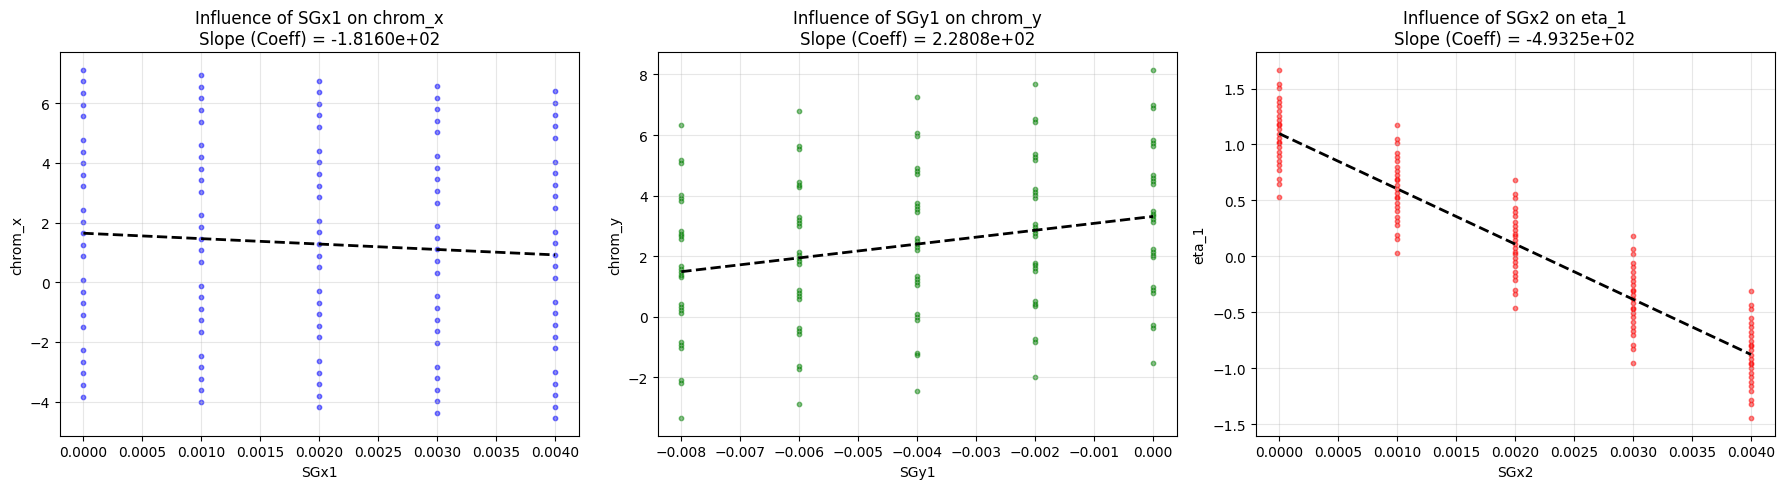

In [29]:
# Выбираем три пары для анализа прямого влияния
pairs = [
    ('SGx1', 'chrom_x', 'blue'),   # Коэффициент A1
    ('SGy1', 'chrom_y', 'green'),  # Коэффициент B3
    ('SGx2', 'eta_1',   'red')     # Коэффициент C1
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (x_col, y_col, color) in enumerate(pairs):
    # Рисуем точки
    axes[i].scatter(df[x_col], df[y_col], alpha=0.5, s=10, c=color)
    
    # Считаем наклон (коэффициент) через линейную регрессию 1D
    m, b = np.polyfit(df[x_col], df[y_col], 1)
    
    # Рисуем линию тренда
    x_range = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    axes[i].plot(x_range, m*x_range + b, color='black', linestyle='--', linewidth=2)
    
    axes[i].set_title(f'Influence of {x_col} on {y_col}\nSlope (Coeff) = {m:.4e}')
    axes[i].set_xlabel(x_col)
    axes[i].set_ylabel(y_col)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

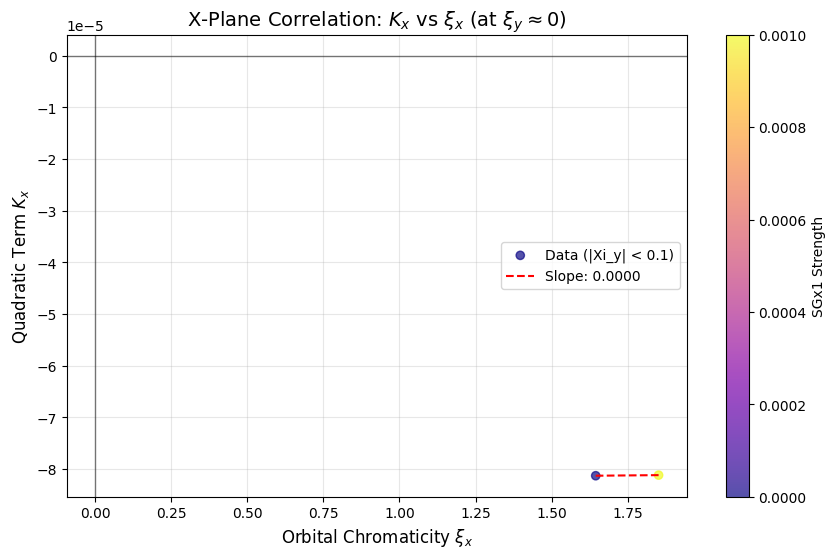

Найдено точек в срезе: 2


In [30]:
# 1. Выбираем допуск (tolerance) для хроматичности Y
# Чем меньше число, тем "тоньше" срез, но меньше точек. 
# Начни с 0.1 или 0.05
tol = 0.1
df_slice = df[(np.abs(df['chrom_y']) < tol)]

# 2. Строим график
plt.figure(figsize=(10, 6))

# Рисуем точки среза
plt.scatter(df_slice['chrom_x'], df_slice['quad_Kx'], 
            c=df_slice['SGx1'], cmap='plasma', alpha=0.7, label=f'Data (|Xi_y| < {tol})')

# 3. Линия тренда (чтобы увидеть наклон/коэффициент)
if len(df_slice) > 1:
    m, b = np.polyfit(df_slice['chrom_x'], df_slice['quad_Kx'], 1)
    x_range = np.linspace(df_slice['chrom_x'].min(), df_slice['chrom_x'].max(), 100)
    plt.plot(x_range, m*x_range + b, color='red', linestyle='--', label=f'Slope: {m:.4f}')

# Оформление
plt.axhline(0, color='black', linewidth=1, alpha=0.5) # Линия нуля для Kx
plt.axvline(0, color='black', linewidth=1, alpha=0.5) # Линия нуля для Xi_x

plt.title(r'X-Plane Correlation: $K_x$ vs $\xi_x$ (at $\xi_y \approx 0$)', fontsize=14)
plt.xlabel(r'Orbital Chromaticity $\xi_x$', fontsize=12)
plt.ylabel(r'Quadratic Term $K_x$', fontsize=12)
plt.colorbar(label='SGx1 Strength')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

print(f"Найдено точек в срезе: {len(df_slice)}")

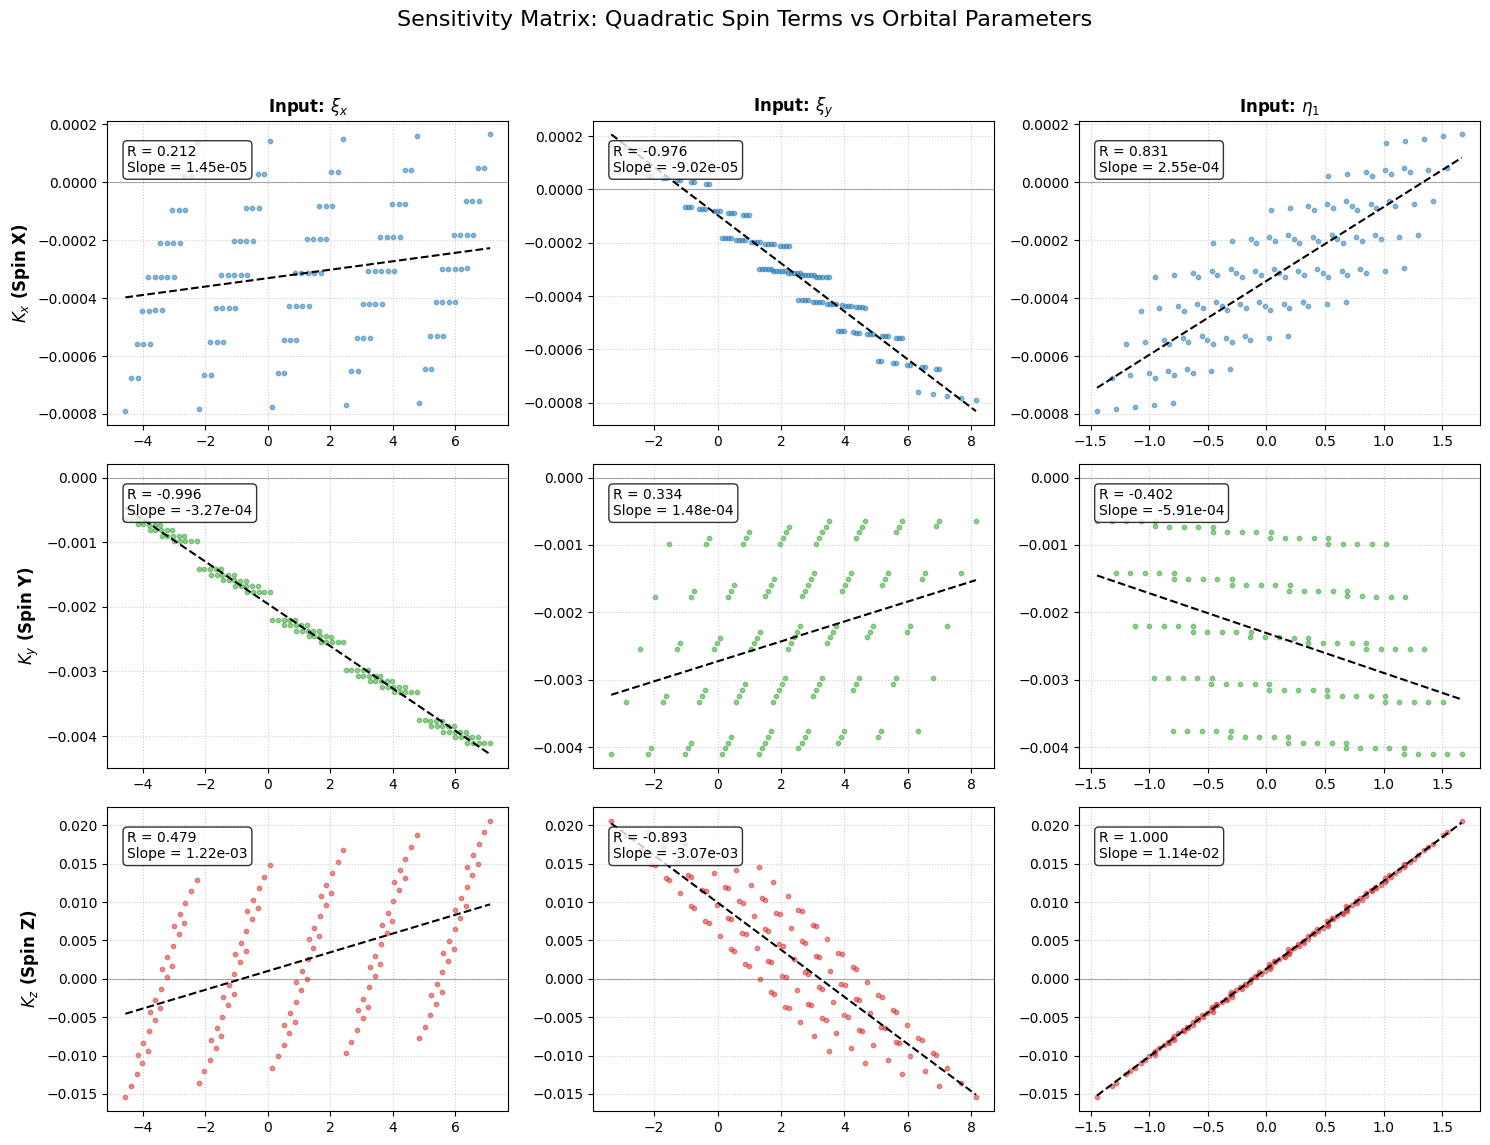

------------------------------
ФИЗИЧЕСКИЕ ВЕСА ВЛИЯНИЯ:
------------------------------
Влияние chrom_x на quad_Kx: 1.4545e-05
Влияние chrom_y на quad_Kx: -9.0185e-05
Влияние eta_1 на quad_Kx: 2.5514e-04
Влияние chrom_x на quad_Ky: -3.2693e-04
Влияние chrom_y на quad_Ky: 1.4785e-04
Влияние eta_1 на quad_Ky: -5.9120e-04
Влияние chrom_x на quad_Kz: 1.2212e-03
Влияние chrom_y на quad_Kz: -3.0715e-03
Влияние eta_1 на quad_Kz: 1.1427e-02


In [31]:
# 1. Параметры для анализа: входы (физика орбиты) и выходы (нелинейность спина)
inputs = ['chrom_x', 'chrom_y', 'eta_1']
outputs = ['quad_Kx', 'quad_Ky', 'quad_Kz'] # Те самые квадратичные члены

# Метки для графиков (LaTeX)
input_labels = [r'$\xi_x$', r'$\xi_y$', r'$\eta_1$']
output_labels = [r'$K_x$ (Spin X)', r'$K_y$ (Spin Y)', r'$K_z$ (Spin Z)']
colors = ['tab:blue', 'tab:green', 'tab:red']

fig, axes = plt.subplots(3, 3, figsize=(15, 12), dpi=100)

for i, y_col in enumerate(outputs):
    for j, x_col in enumerate(inputs):
        ax = axes[i, j]
        
        # Данные маппинга
        ax.scatter(df[x_col], df[y_col], alpha=0.5, s=10, color=colors[i])
        
        # Линейная аппроксимация (поиск коэффициента влияния)
        # y = m*x + b
        m, b = np.polyfit(df[x_col], df[y_col], 1)
        x_fit = np.linspace(df[x_col].min(), df[x_col].max(), 100)
        ax.plot(x_fit, m*x_fit + b, color='black', linestyle='--', linewidth=1.5)
        
        # Статистика для статьи
        r_corr = df[x_col].corr(df[y_col])
        
        # Оформление
        if i == 0: ax.set_title(f'Input: {input_labels[j]}', fontsize=12, fontweight='bold')
        if j == 0: ax.set_ylabel(output_labels[i], fontsize=12, fontweight='bold')
        
        # Вывод коэффициентов прямо на график
        ax.text(0.05, 0.92, f'R = {r_corr:.3f}\nSlope = {m:.2e}', 
                transform=ax.transAxes, fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        ax.axhline(0, color='black', linewidth=0.8, alpha=0.3)
        ax.grid(True, linestyle=':', alpha=0.6)

plt.suptitle('Sensitivity Matrix: Quadratic Spin Terms vs Orbital Parameters', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 2. Печать итоговой таблицы коэффициентов для текста статьи
print("-" * 30)
print("ФИЗИЧЕСКИЕ ВЕСА ВЛИЯНИЯ:")
print("-" * 30)
for i, out in enumerate(outputs):
    for j, inp in enumerate(inputs):
        m, _ = np.polyfit(df[inp], df[out], 1)
        print(f"Влияние {inp} на {out}: {m:.4e}")

In [32]:
correlation_matrix = df[['chrom_x', 'chrom_y', 'eta_1']].corr()
print("ВЗАИМОСВЯЗЬ ПЛОСКОСТЕЙ (Correlation):")
print(correlation_matrix)

ВЗАИМОСВЯЗЬ ПЛОСКОСТЕЙ (Correlation):
          chrom_x   chrom_y     eta_1
chrom_x  1.000000 -0.418192  0.464930
chrom_y -0.418192  1.000000 -0.886061
eta_1    0.464930 -0.886061  1.000000


In [33]:
# 1. ПОДГОТОВКА ДАННЫХ
# Матрица токов (дизайн-матрица) + столбец для константы (натуральные параметры)
X_design = np.column_stack([df['SGx1'], df['SGx2'], df['SGy1'], np.ones(len(df))])

def extract_plane(target_col):
    # Находим коэффициенты методом наименьших квадратов
    # beta = [Coeff_I1, Coeff_I2, Coeff_I3, Natural_Value]
    beta, residuals, rank, s = np.linalg.lstsq(X_design, df[target_col], rcond=None)
    return beta

# 2. ИЗВЛЕКАЕМ КОЭФФИЦИЕНТЫ
coeffs_x = extract_plane('chrom_x') # A1, A2, A3, xi_x0
coeffs_y = extract_plane('chrom_y') # B1, B2, B3, xi_y0
coeffs_z = extract_plane('eta_1')   # C1, C2, C3, eta_1_0

# Собираем матрицу отклика R (3x3)
R = np.array([
    coeffs_x[:3], # Влияние на Xi_x
    coeffs_y[:3], # Влияние на Xi_y
    coeffs_z[:3]  # Влияние на Eta_1
])

# Вектор натуральных параметров (значения при выключенных секступолях)
natural_vec = np.array([coeffs_x[3], coeffs_y[3], coeffs_z[3]])

# 3. РЕШАЕМ СИСТЕМУ ДЛЯ (0, 0, 0)
# Уравнение: R * I + natural = 0  =>  R * I = -natural
try:
    ideal_currents = np.linalg.solve(R, -natural_vec)
    I1, I2, I3 = ideal_currents

    print("="*65)
    print("   РЕЗУЛЬТАТЫ ЛИНЕЙНОЙ ЭКСТРАКЦИИ (FR 3 MODE)   ")
    print("="*65)
    print(f"МАТРИЦА ОТКЛИКА (Response Matrix R):")
    print(pd.DataFrame(R, index=['Xi_x', 'Xi_y', 'Eta_1'], 
                          columns=['SGx1', 'SGx2', 'SGy1']))
    print("-" * 65)
    print(f"НАТУРАЛЬНЫЕ ПАРАМЕТРЫ (БЕЗ СЕКСТУПОЛЕЙ):")
    print(f"  Xi_x_nat  = {natural_vec[0]:.4f}")
    print(f"  Xi_y_nat  = {natural_vec[1]:.4f}")
    print(f"  Eta_1_nat = {natural_vec[2]:.4e}")
    print("-" * 65)
    print(f"ИДЕАЛЬНЫЕ ТОКИ ДЛЯ ПОЛНОЙ КОМПЕНСАЦИИ (0,0,0):")
    print(f"  SGx1 = {I1:.6f}")
    print(f"  SGx2 = {I2:.6f}")
    print(f"  SGy1 = {I3:.6f}")
    print("="*65)

except np.linalg.LinAlgError:
    print("ОШИБКА: Матрица вырождена! Секступоли влияют на параметры слишком похоже.")

   РЕЗУЛЬТАТЫ ЛИНЕЙНОЙ ЭКСТРАКЦИИ (FR 3 MODE)   
МАТРИЦА ОТКЛИКА (Response Matrix R):
              SGx1         SGx2         SGy1
Xi_x   -181.602324  -388.136080 -1175.384736
Xi_y   1162.952222  1258.582701   228.075734
Eta_1  -123.717932  -493.253674   -80.550263
-----------------------------------------------------------------
НАТУРАЛЬНЫЕ ПАРАМЕТРЫ (БЕЗ СЕКСТУПОЛЕЙ):
  Xi_x_nat  = -2.2806
  Xi_y_nat  = -1.5320
  Eta_1_nat = 1.0225e+00
-----------------------------------------------------------------
ИДЕАЛЬНЫЕ ТОКИ ДЛЯ ПОЛНОЙ КОМПЕНСАЦИИ (0,0,0):
  SGx1 = -0.001200
  SGx2 = 0.002812
  SGy1 = -0.002684


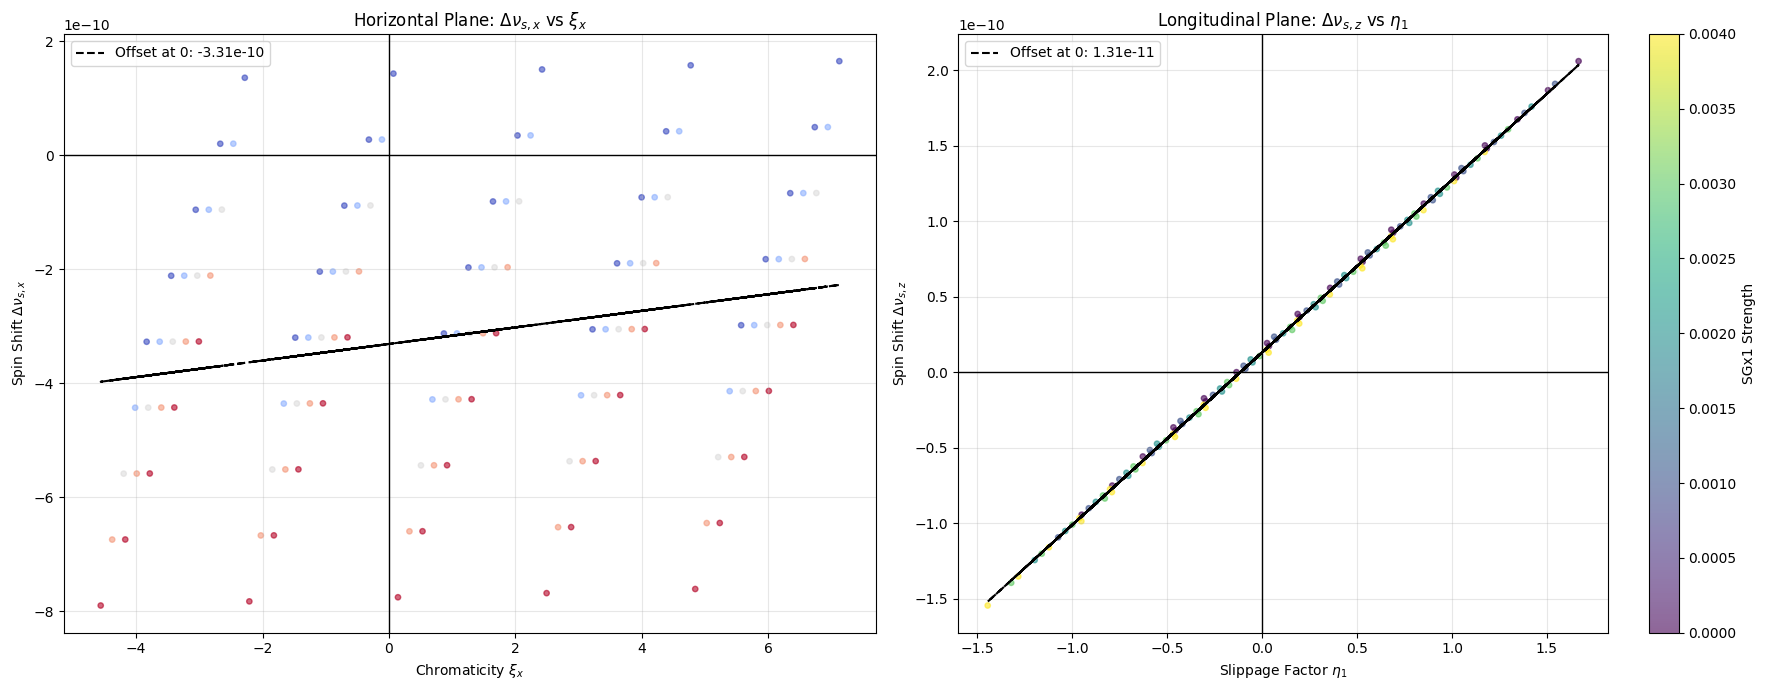

ПРОГНОЗ ДЛЯ СТАТЬИ:
При eta_1 = 0, спиновый сдвиг spin_z составляет 1.31e-11
Чтобы обнулить spin_z, нужно выставить eta_1 = -1.1492e-01


In [34]:
# Настройка графиков
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Плоскость X: Влияние хроматичности на горизонтальный спин-тюн
ax1 = axes[0]
sc1 = ax1.scatter(df['chrom_x'], df['spin_x'], c=df['SGx1'], cmap='coolwarm', alpha=0.6, s=15)
m1, b1 = np.polyfit(df['chrom_x'], df['spin_x'], 1)
ax1.plot(df['chrom_x'], m1*df['chrom_x'] + b1, color='black', ls='--', label=f'Offset at 0: {b1:.2e}')
ax1.set_title(r'Horizontal Plane: $\Delta \nu_{s,x}$ vs $\xi_x$')
ax1.set_xlabel(r'Chromaticity $\xi_x$')
ax1.set_ylabel(r'Spin Shift $\Delta \nu_{s,x}$')
ax1.axvline(0, color='black', lw=1); ax1.axhline(0, color='black', lw=1)
ax1.legend(); ax1.grid(True, alpha=0.3)

# 2. Плоскость Z: Влияние Eta_1 на продольный спин-тюн (Самое важное!)
ax2 = axes[1]
# Здесь мы ищем точку, где спин-тюн (spin_z) обнуляется. 
# По твоей формуле это должно зависеть от eta_1
sc2 = ax2.scatter(df['eta_1'], df['spin_z'], c=df['SGx1'], cmap='viridis', alpha=0.6, s=15)
m2, b2 = np.polyfit(df['eta_1'], df['spin_z'], 1)
ax2.plot(df['eta_1'], m2*df['eta_1'] + b2, color='black', ls='--', label=f'Offset at 0: {b2:.2e}')
ax2.set_title(r'Longitudinal Plane: $\Delta \nu_{s,z}$ vs $\eta_1$')
ax2.set_xlabel(r'Slippage Factor $\eta_1$')
ax2.set_ylabel(r'Spin Shift $\Delta \nu_{s,z}$')
ax2.axvline(0, color='black', lw=1); ax2.axhline(0, color='black', lw=1)
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.colorbar(sc2, ax=ax2, label='SGx1 Strength')
plt.tight_layout()
plt.show()

print(f"ПРОГНОЗ ДЛЯ СТАТЬИ:")
print(f"При eta_1 = 0, спиновый сдвиг spin_z составляет {b2:.2e}")
print(f"Чтобы обнулить spin_z, нужно выставить eta_1 = {-b2/m2:.4e}")

In [35]:
# 1. Извлекаем коэффициенты влияния на СПИН-ТЮНЫ (spin_x, spin_y, spin_z)
# Матрица признаков: [SGx1, SGx2, SGy1, const]
X_design = np.column_stack([df['SGx1'], df['SGx2'], df['SGy1'], np.ones(len(df))])

def get_spin_coeffs(target_col):
    # Решаем систему: X * beta = target
    beta, _, _, _ = np.linalg.lstsq(X_design, df[target_col], rcond=None)
    return beta[:3], beta[3] # Возвращаем веса секступолей и натуральный сдвиг

# Получаем веса для каждой компоненты спин-тюна
R_x_coeffs, spin_x_nat = get_spin_coeffs('spin_x')
R_y_coeffs, spin_y_nat = get_spin_coeffs('spin_y')
R_z_coeffs, spin_z_nat = get_spin_coeffs('spin_z')

# 2. Собираем СПИНОВУЮ МАТРИЦУ ОТКЛИКА (3x3)
R_spin = np.array([R_x_coeffs, R_y_coeffs, R_z_coeffs])
nat_spin_vec = np.array([spin_x_nat, spin_y_nat, spin_z_nat])

# 3. РЕШАЕМ СИСТЕМУ: R_spin * I + nat_spin = 0
try:
    ideal_spin_currents = np.linalg.solve(R_spin, -nat_spin_vec)
    I1_s, I2_s, I3_s = ideal_spin_currents

    # 4. Проверяем, какая орбита (Xi, Eta) будет в этой "спиновой" точке
    # Используем орбитальную матрицу R и natural_vec, которые мы нашли ранее
    orbital_at_spin_ideal = R @ ideal_spin_currents + natural_vec

    print("="*65)
    print("   ИДЕАЛЬНЫЕ ТОКИ ДЛЯ ДОСТИЖЕНИЯ ДЕЛЬТА СПИН-ТЮНА = 0    ")
    print("="*65)
    print(f"Требуемые значения секступолей:")
    print(f"  SGx1 = {I1_s:.6f}")
    print(f"  SGx2 = {I2_s:.6f}")
    print(f"  SGy1 = {I3_s:.6f}")
    print("-" * 65)
    print(f"ОРБИТАЛЬНЫЕ ПАРАМЕТРЫ В ЭТОЙ ТОЧКЕ (Офсеты):")
    print(f"  Xi_x  = {orbital_at_spin_ideal[0]:.4f}")
    print(f"  Xi_y  = {orbital_at_spin_ideal[1]:.4f}")
    print(f"  Eta_1 = {orbital_at_spin_ideal[2]:.4e}")
    print("="*65)
    print(nat_spin_vec)

except np.linalg.LinAlgError:
    print("Ошибка: Матрица вырождена.")

   ИДЕАЛЬНЫЕ ТОКИ ДЛЯ ДОСТИЖЕНИЯ ДЕЛЬТА СПИН-ТЮНА = 0    
Требуемые значения секступолей:
  SGx1 = -0.001167
  SGx2 = 0.002274
  SGy1 = 0.002029
-----------------------------------------------------------------
ОРБИТАЛЬНЫЕ ПАРАМЕТРЫ В ЭТОЙ ТОЧКЕ (Офсеты):
  Xi_x  = -5.3364
  Xi_y  = 0.4362
  Eta_1 = -1.1848e-01
[ 1.35779666e-10 -9.87060842e-10  1.29024379e-10]


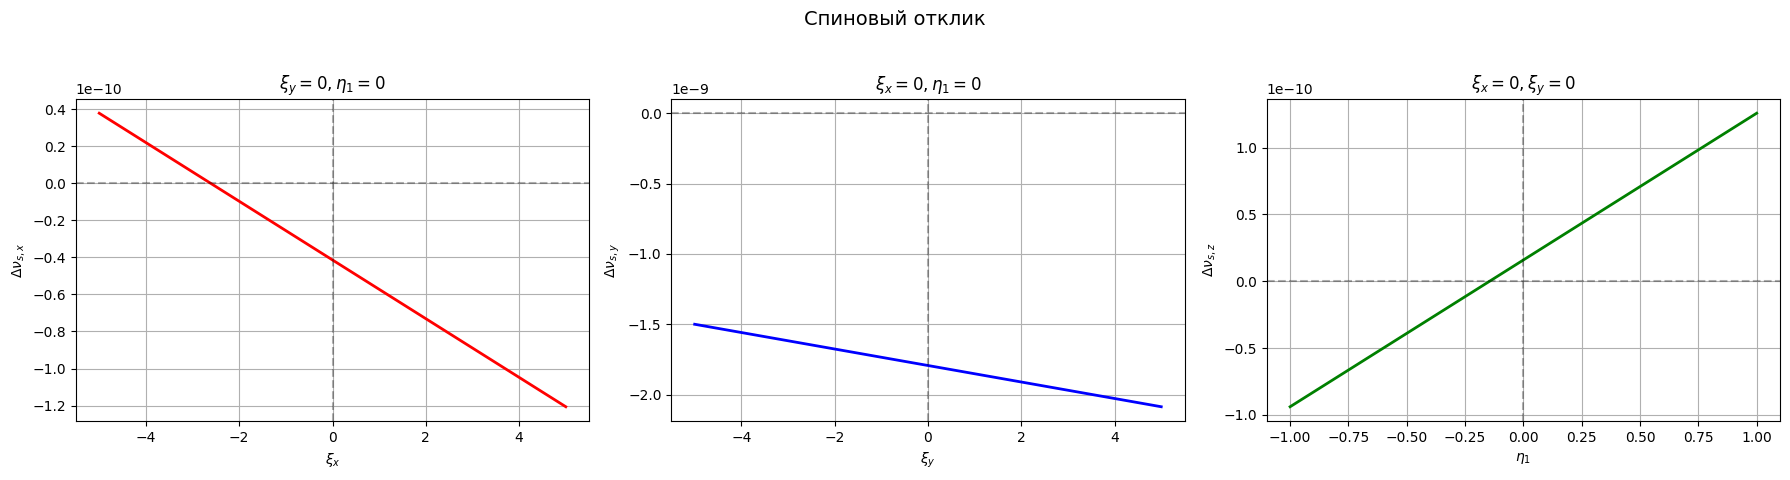

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Настройка стилей для статьи
plt.rcParams.update({'font.size': 10, 'axes.grid': True})

# 1. Подготовка диапазонов (адаптируйте под ваши данные)
steps = 100
xi_x_range = np.linspace(-5, 5, steps)
xi_y_range = np.linspace(-5, 5, steps)
eta_1_range = np.linspace(-1, 1, steps)

# Списки для результатов
s_x_res, s_y_res, s_z_res = [], [], []
s_x_res_1, s_y_res_1, s_z_res_1 = [], [], []

# 2. Расчет зависимостей
for i in range(steps):
    # А) spin_x от Xi_x (Xi_y=0, Eta_1=0)
    target_a = np.array([xi_x_range[i], 0, 0])
    curr_a = np.linalg.solve(R, target_a - natural_vec)
    s_x_res.append(np.dot(R_x_coeffs, curr_a) + spin_x_nat)

    # Б) spin_y от Xi_y (Xi_x=0, Eta_1=0)
    target_b = np.array([0, xi_y_range[i], 0])
    curr_b = np.linalg.solve(R, target_b - natural_vec)
    s_y_res.append(np.dot(R_y_coeffs, curr_b) + spin_y_nat)

    # В) spin_z от Eta_1 (Xi_x=0, Xi_y=0)
    target_c = np.array([0, 0, eta_1_range[i]])
    curr_c = np.linalg.solve(R, target_c - natural_vec)
    s_z_res.append(np.dot(R_z_coeffs, curr_c) + spin_z_nat)

# 3. Визуализация (3 панели)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Спиновый отклик', fontsize=14)

# График 1: spin_x(Xi_x)
ax1.plot(xi_x_range, s_x_res, 'r-', lw=2)
ax1.set_xlabel(r'$\xi_x$')
ax1.set_ylabel(r'$\Delta \nu_{s, x}$')
ax1.axhline(0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
ax1.set_title(r'$\xi_y=0, \eta_1=0$')

# График 2: spin_y(Xi_y)
ax2.plot(xi_y_range, s_y_res, 'b-', lw=2)
ax2.set_xlabel(r'$\xi_y$')
ax2.set_ylabel(r'$\Delta \nu_{s, y}$')
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
ax2.set_title(r'$\xi_x=0, \eta_1=0$')

# График 3: spin_z(Eta_1)
ax3.plot(eta_1_range, s_z_res, 'g-', lw=2)
ax3.set_xlabel(r'$\eta_1$')
ax3.set_ylabel(r'$\Delta \nu_{s, z}$')
ax3.axhline(0, color='k', linestyle='--', alpha=0.3)
ax3.axvline(0, color='k', linestyle='--', alpha=0.3)
ax3.set_title(r'$\xi_x=0, \xi_y=0$')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [37]:
import numpy as np

# =========================
# 1. ДИЗАЙН-МАТРИЦА
# =========================
X_design = np.column_stack([
    df['SGx1'],
    df['SGx2'],
    df['SGy1'],
    np.ones(len(df))
])

# =========================
# 2. ФУНКЦИЯ ДЛЯ КОЭФФИЦИЕНТОВ
# =========================
def get_spin_coeffs(target_col):
    beta, _, _, _ = np.linalg.lstsq(X_design, df[target_col], rcond=None)
    return beta[:3], beta[3]  # коэффициенты + константа


# =========================
# 3. МАТРИЦЫ ДЛЯ 2 ЧАСТИЦ
# =========================

# --- Частица 0 ---
R0_x, nat0_x = get_spin_coeffs('spin_x')
R0_y, nat0_y = get_spin_coeffs('spin_y')
R0_z, nat0_z = get_spin_coeffs('spin_z')

R_spin_0 = np.array([R0_x, R0_y, R0_z])
nat_0 = np.array([nat0_x, nat0_y, nat0_z])

# --- Частица 1 ---
R1_x, nat1_x = get_spin_coeffs('spin_x_1')
R1_y, nat1_y = get_spin_coeffs('spin_y_1')
R1_z, nat1_z = get_spin_coeffs('spin_z_1')

R_spin_1 = np.array([R1_x, R1_y, R1_z])
nat_1 = np.array([nat1_x, nat1_y, nat1_z])


# =========================
# 4. ОБЪЕДИНЁННАЯ СИСТЕМА
# =========================

A = np.vstack([
    R_spin_0,
    R_spin_1
])

b = -np.hstack([
    nat_0,
    nat_1
])


# =========================
# 5. РЕШЕНИЕ (least squares)
# =========================
I_opt, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)

I1, I2, I3 = I_opt


# =========================
# 6. ПРОВЕРКА
# =========================
spin0_check =nat_0
spin1_check =nat_1


# =========================
# 7. ВЫВОД
# =========================
print("="*65)
print("     ОПТИМАЛЬНЫЕ ТОКИ (multi-particle matching)")
print("="*65)

print(f"SGx1 = {I1:.6f}")
print(f"SGx2 = {I2:.6f}")
print(f"SGy1 = {I3:.6f}")

print("-"*65)
print("Spin tune (частица 0):")
print(f"  x = {spin0_check[0]:.3e}")
print(f"  y = {spin0_check[1]:.3e}")
print(f"  z = {spin0_check[2]:.3e}")

print("-"*65)
print("Spin tune (частица 1):")
print(f"  x = {spin1_check[0]:.3e}")
print(f"  y = {spin1_check[1]:.3e}")
print(f"  z = {spin1_check[2]:.3e}")

print("-"*65)
print(f"Residuals = {residuals}")
print(f"Rank = {rank}")
print(f"Cond(A) = {np.linalg.cond(A):.3e}")
print("="*65)

     ОПТИМАЛЬНЫЕ ТОКИ (multi-particle matching)
SGx1 = -0.001167
SGx2 = 0.002275
SGy1 = 0.002027
-----------------------------------------------------------------
Spin tune (частица 0):
  x = 1.358e-10
  y = -9.871e-10
  z = 1.290e-10
-----------------------------------------------------------------
Spin tune (частица 1):
  x = 5.434e-10
  y = -3.948e-09
  z = 3.226e-11
-----------------------------------------------------------------
Residuals = [3.58228328e-25]
Rank = 3
Cond(A) = 5.920e+01


Сохранено: magnetic_mod_FR0_x.png
Сохранено: magnetic_mod_FR0_y.png
Сохранено: magnetic_mod_FR0_z.png


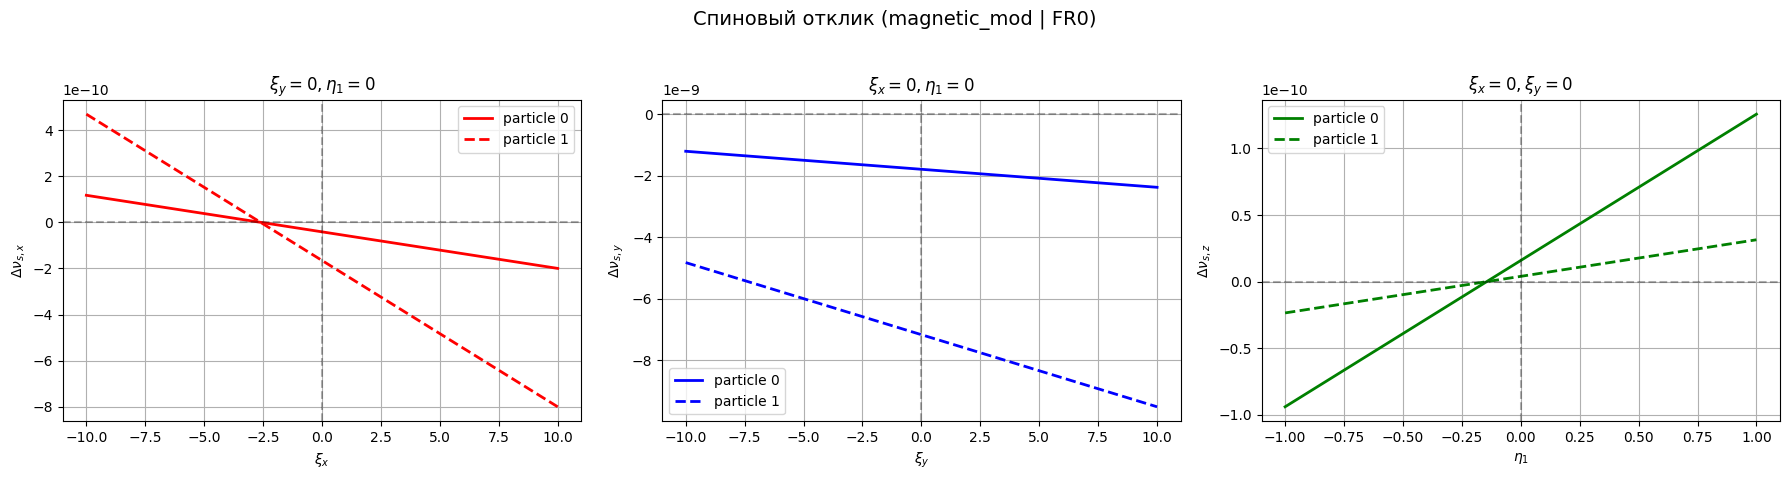

In [38]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 10, 'axes.grid': True})

# =========================
# 1. ДИАПАЗОНЫ
# =========================
steps = 100
xi_x_range = np.linspace(-10, 10, steps)
xi_y_range = np.linspace(-10, 10, steps)
eta_1_range = np.linspace(-1, 1, steps)

# =========================
# 2. СПИСКИ
# =========================
s_x_res, s_y_res, s_z_res = [], [], []
s_x_res_1, s_y_res_1, s_z_res_1 = [], [], []

# =========================
# 3. РАСЧЁТ
# =========================
for i in range(steps):

    # --- A) spin_x vs Xi_x ---
    target_a = np.array([xi_x_range[i], 0, 0])
    curr_a = np.linalg.solve(R, target_a - natural_vec)

    s_x_res.append(np.dot(R_x_coeffs, curr_a) + spin_x_nat)
    s_x_res_1.append(np.dot(R1_x, curr_a) + nat1_x)


    # --- B) spin_y vs Xi_y ---
    target_b = np.array([0, xi_y_range[i], 0])
    curr_b = np.linalg.solve(R, target_b - natural_vec)

    s_y_res.append(np.dot(R_y_coeffs, curr_b) + spin_y_nat)
    s_y_res_1.append(np.dot(R1_y, curr_b) + nat1_y)


    # --- C) spin_z vs Eta_1 ---
    target_c = np.array([0, 0, eta_1_range[i]])
    curr_c = np.linalg.solve(R, target_c - natural_vec)

    s_z_res.append(np.dot(R_z_coeffs, curr_c) + spin_z_nat)
    s_z_res_1.append(np.dot(R1_z, curr_c) + nat1_z)


# Параметры для каждой плоскости: (данные_x, данные_y0, данные_y1, цвет, подпись_x, подпись_y, заголовок, суффикс_файла)
plot_configs = [
    (xi_x_range, s_x_res, s_x_res_1, 'r', r'$\xi_x$', r'$\Delta \nu_{s, x}$', r'$\xi_y=0, \eta_1=0$', 'x'),
    (xi_y_range, s_y_res, s_y_res_1, 'b', r'$\xi_y$', r'$\Delta \nu_{s, y}$', r'$\xi_x=0, \eta_1=0$', 'y'),
    (eta_1_range, s_z_res, s_z_res_1, 'g', r'$\eta_1$', r'$\Delta \nu_{s, z}$', r'$\xi_x=0, \xi_y=0$', 'z')
]

# Создаем общую фигуру для отображения "в ряд" в интерфейсе
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Спиновый отклик ({lattice} | {mode})', fontsize=14)

for i, (x_data, y0, y1, color, xl, yl, title, plane) in enumerate(plot_configs):
    ax = axes[i]
    
    # 1. Отрисовка на общем полотне
    ax.plot(x_data, y0, color + '-', lw=2, label='particle 0')
    ax.plot(x_data, y1, color + '--', lw=2, label='particle 1')
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
    ax.axhline(0, color='k', linestyle='--', alpha=0.3)
    ax.axvline(0, color='k', linestyle='--', alpha=0.3)
    ax.legend()

    # 2. СОХРАНЕНИЕ ОТДЕЛЬНОГО ФАЙЛА
    # Создаем временную фигуру такого же размера, как один подграфик
    temp_fig, temp_ax = plt.subplots(figsize=(6, 5))
    temp_ax.plot(x_data, y0, color + '-', lw=2, label='particle 0')
    temp_ax.plot(x_data, y1, color + '--', lw=2, label='particle 1')
    temp_ax.set_xlabel(xl)
    temp_ax.set_ylabel(yl)
    temp_ax.set_title(title)
    temp_ax.axhline(0, color='k', linestyle='--', alpha=0.3)
    temp_ax.axvline(0, color='k', linestyle='--', alpha=0.3)
    temp_ax.legend()
    temp_ax.grid(True)
    
    save_name = f"{lattice}_{mode}_{plane}.png"
    temp_fig.savefig(os.path.join(base_path, save_name), dpi=300, bbox_inches='tight')
    plt.close(temp_fig) # Закрываем временную фигуру, чтобы не дублировать вывод
    print(f"Сохранено: {save_name}")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [14]:
# Расчет суммарного квадратичного члена (целевая функция SCT)
df['K_total'] = np.sqrt(df['quad_Kx']**2 + df['quad_Ky']**2 + df['quad_Kz']**2)

In [15]:
# Сетка для интерполяции в координатах хроматичностей
cxi = np.linspace(df['chrom_x'].min(), df['chrom_x'].max(), 100)
cyi = np.linspace(df['chrom_y'].min(), df['chrom_y'].max(), 100)
CX, CY = np.meshgrid(cxi, cyi)

# Интерполяция K_total на сетку хроматичностей
KZ = griddata((df['chrom_x'], df['chrom_y']), df['K_total'], (CX, CY), method='cubic')

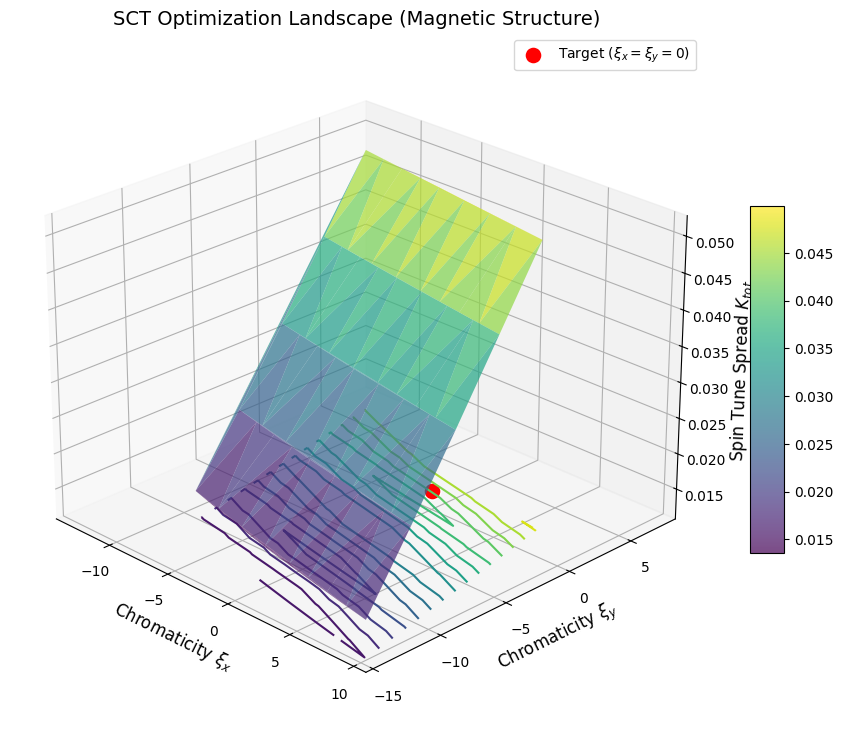

In [16]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d') 

# Поверхность
surf = ax.plot_trisurf(df['chrom_x'], df['chrom_y'], df['K_total'], 
                      cmap='viridis', edgecolor='none', alpha=0.7, antialiased=True)

# Проекция изолиний на "пол" (Z_min)
# Это покажет "кольца" сходимости к нулю
offset = df['K_total'].min() - (df['K_total'].max() - df['K_total'].min())*0.1
ax.tricontour(df['chrom_x'], df['chrom_y'], df['K_total'], 
              levels=15, cmap='viridis', linestyles="solid", offset=offset)

# Точка идеальной хроматичности (0, 0)
ax.scatter(0, 0, [df['K_total'].min()], color='red', s=150, 
           label=r'Target ($\xi_x=\xi_y=0$)', edgecolors='white', zorder=5)

ax.set_xlabel('Chromaticity $\\xi_x$', fontsize=12)
ax.set_ylabel('Chromaticity $\\xi_y$', fontsize=12)
ax.set_zlabel('Spin Tune Spread $K_{tot}$', fontsize=12)
ax.set_title('SCT Optimization Landscape (Magnetic Structure)', fontsize=14)
ax.view_init(elev=25, azim=-45) # Поверните для лучшего обзора "чаши"

plt.colorbar(surf, shrink=0.5, aspect=10)
plt.legend()
plt.show()

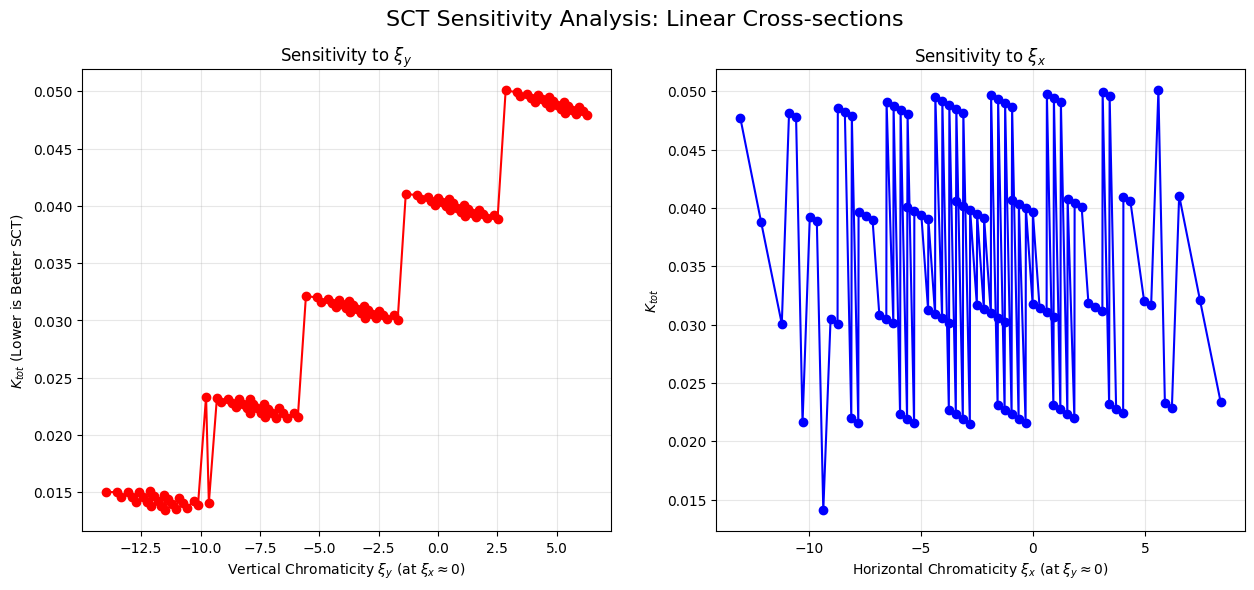

In [17]:
# Фильтруем данные, где одна из хроматичностей близка к нулю (например, в пределах 0.5)
threshold = 10
near_x0 = df[df['chrom_x'].abs() < threshold].sort_values('chrom_y')
near_y0 = df[df['chrom_y'].abs() < threshold].sort_values('chrom_x')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Левый график: Зависимость от вертикального хроматизма
ax1.plot(near_x0['chrom_y'], near_x0['K_total'], 'ro-', label='SCT Spread')
ax1.set_xlabel('Vertical Chromaticity $\\xi_y$ (at $\\xi_x \\approx 0$)')
ax1.set_ylabel('$K_{tot}$ (Lower is Better SCT)')
ax1.grid(True, alpha=0.3)
ax1.set_title('Sensitivity to $\\xi_y$')

# Правый график: Зависимость от горизонтального хроматизма
ax2.plot(near_y0['chrom_x'], near_y0['K_total'], 'bo-', label='SCT Spread')
ax2.set_xlabel('Horizontal Chromaticity $\\xi_x$ (at $\\xi_y \\approx 0$)')
ax2.set_ylabel('$K_{tot}$')
ax2.grid(True, alpha=0.3)
ax2.set_title('Sensitivity to $\\xi_x$')

plt.suptitle('SCT Sensitivity Analysis: Linear Cross-sections', fontsize=16)
plt.show()

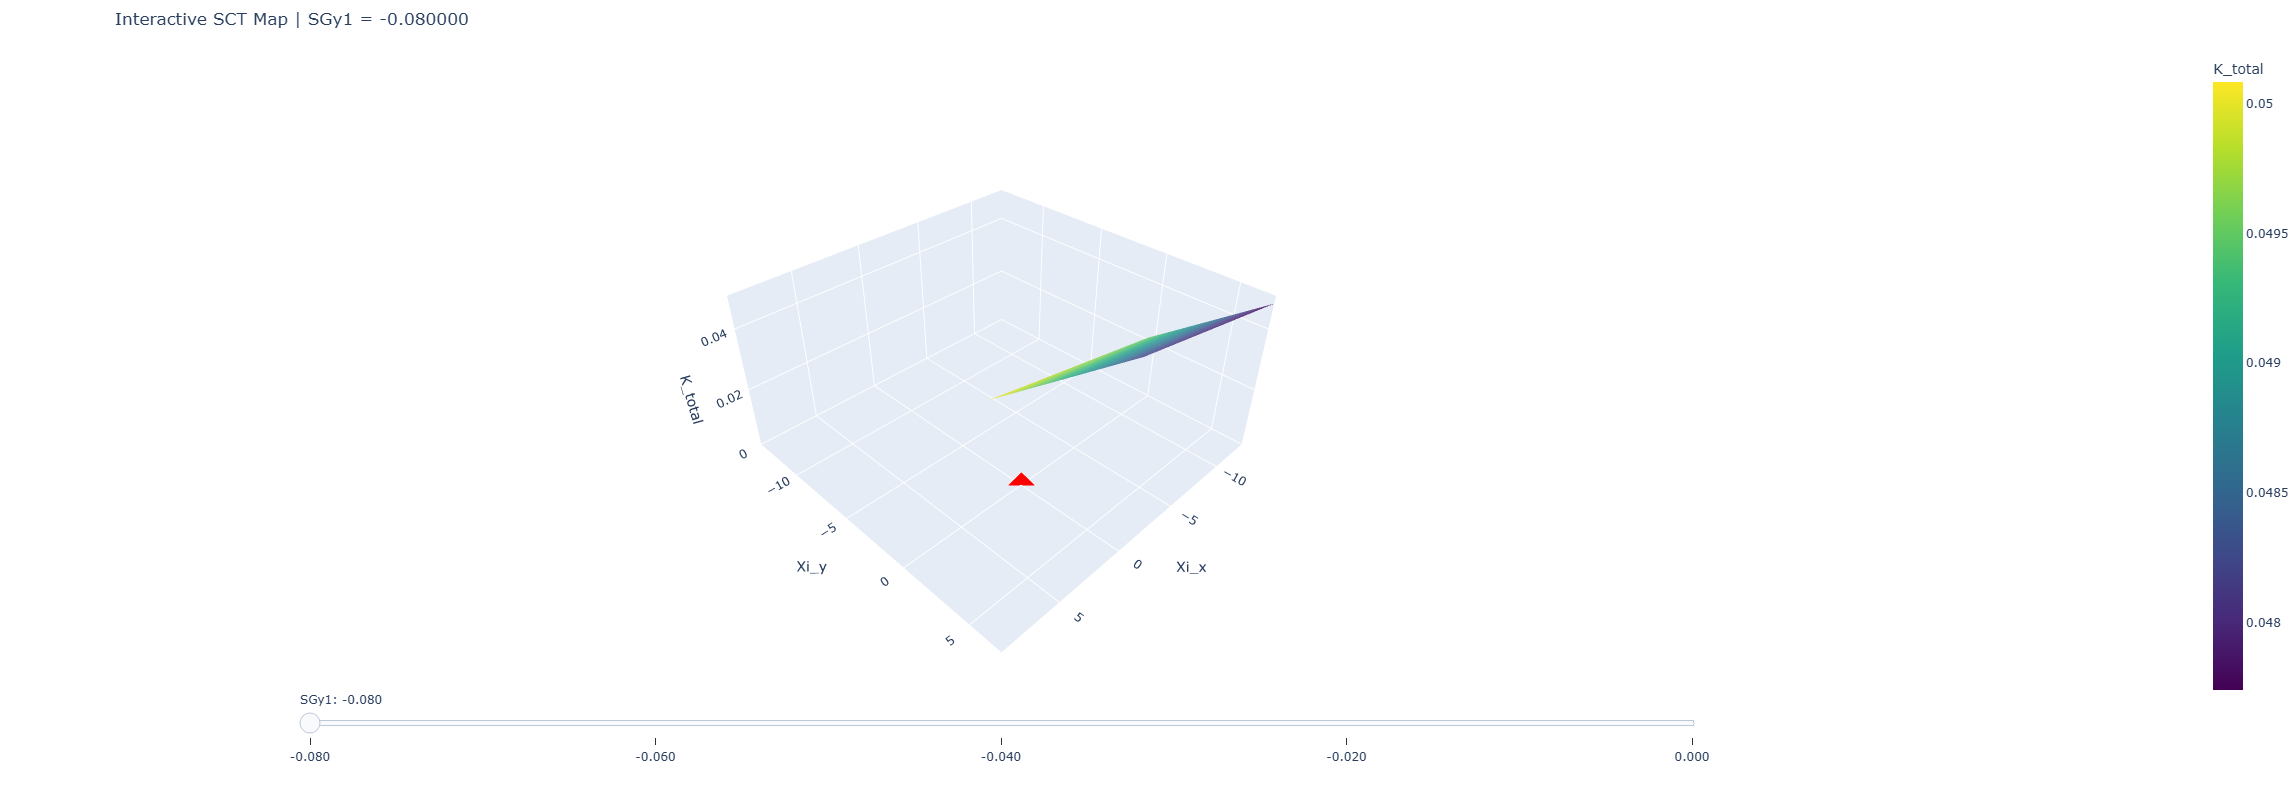

In [18]:
# 1. Выделяем натуральную точку (где все секступоли = 0)
#nat_row = df[(df['SGx1'] == 0) & (df['SGx2'] == 0) & (df['SGy1'] == 0) & (df['SGy2'] == 0)].iloc[0]

# 2. Список уникальных значений SGy1 для поверхностей
sgy_values = np.sort(df['SGy1'].unique())
num_slices = len(sgy_values)

fig = go.Figure()

# 3. Добавляем ПОВЕРХНОСТИ
for i, sgy in enumerate(sgy_values):
    df_slice = df[df['SGy1'] == sgy]
    fig.add_trace(go.Mesh3d(
        x=df_slice['chrom_x'], y=df_slice['chrom_y'], z=df_slice['K_total'],
        intensity=df_slice['K_total'], colorscale='Viridis', opacity=0.8,
        visible=(i == 0), showscale=True,
        colorbar=dict(title="K_total", x=1.1)
    ))

# 4. Добавляем "Идеальную цель" (0,0,0) - индекс в списке traces: num_slices
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers', marker=dict(size=10, color='red', symbol='diamond', line=dict(width=2, color='white')),
    name='Ideal Target (0,0,0)', visible=True
))

# 6. Настройка ПОЛЗУНКА с учетом двух постоянных точек
steps = []
for i, sgy in enumerate(sgy_values):
    # Маска видимости: i-я поверхность + Target + Natural
    # Всего элементов в fig.data: num_slices (поверхности) + 2 (точки)
    vis_mask = [False] * num_slices + [True, True] 
    vis_mask[i] = True
    
    steps.append(dict(
        method="update",
        label=f"{sgy:.3f}",
        args=[{"visible": vis_mask},
              {"title": f"SCT Map | SGy1 = {sgy:.6f}"}]
    ))

fig.update_layout(
    sliders=[dict(
        active=0, len=0.7, x=0.15, y=0.05,
        steps=steps, currentvalue={"prefix": "SGy1: "}
    )],
    title=f"Interactive SCT Map | SGy1 = {sgy_values[0]:.6f}",
    scene=dict(
        xaxis_title='Xi_x', yaxis_title='Xi_y', zaxis_title='K_total',
        xaxis=dict(range=[df['chrom_x'].min(), df['chrom_x'].max()]),
        yaxis=dict(range=[df['chrom_y'].min(), df['chrom_y'].max()]),
        zaxis=dict(range=[0, df['K_total'].max()]),
        aspectratio=dict(x=1, y=1, z=0.5)
    ),
    margin=dict(l=0, r=100, b=100, t=50),
    height=800
)

fig.show()

In [19]:
# Нормализуем параметры (делим на макс. значения в выборке), 
# чтобы Xi и K_total вносили равный вклад в "дистанцию"
df['dist_norm'] = np.sqrt(
    (df['chrom_x'] / df['chrom_x'].std())**2 + 
    (df['chrom_y'] / df['chrom_y'].std())**2 + 
    (df['K_total'] / df['K_total'].std())**2
)

best_idx = df['dist_norm'].idxmin()
best_point = df.loc[best_idx]

print("--- Анализ физического оптимума (Mapping Result) ---")
print(f"Минимальная дефазировка достигнута при:")
print(f"Sextupoles: SGx1={best_point['SGx1']:.2f},SGx2={best_point['SGx2']:.2f}, SGy1={best_point['SGy1']:.2f}")
print(f"  Xi_x: {best_point['chrom_x']:.4f},  Xi_y: {best_point['chrom_y']:.4f}")
print(f"  Kx = {best_point['quad_Kx']:.6e}")
print(f"  Ky = {best_point['quad_Ky']:.6e}")
print(f"  Kz = {best_point['quad_Kz']:.6e}")
print(f"  K_tot: {best_point['K_total']:.2e} (Spread)")

--- Анализ физического оптимума (Mapping Result) ---
Минимальная дефазировка достигнута при:
Sextupoles: SGx1=0.00,SGx2=0.04, SGy1=-0.02
  Xi_x: -0.3289,  Xi_y: -7.2728
  Kx = -1.238374e-03
  Ky = -2.012538e-02
  Kz = 7.556894e-03
  K_tot: 2.15e-02 (Spread)


In [20]:
from scipy.interpolate import LinearNDInterpolator
from scipy.optimize import minimize
import numpy as np

# 1. СТРОИМ МОДЕЛИ (LinearNDInterpolator — самый стабильный для 3D сеток)
# Используем координаты всех точек сканирования
points = df[['SGx1', 'SGx2', 'SGy1']].values

f_cx = LinearNDInterpolator(points, df['chrom_x'])
f_cy = LinearNDInterpolator(points, df['chrom_y'])
f_kx = LinearNDInterpolator(points, df['quad_Kx'])
f_ky = LinearNDInterpolator(points, df['quad_Ky'])
f_kz = LinearNDInterpolator(points, df['quad_Kz'])
f_sx = LinearNDInterpolator(points, df['spin_x'])
f_sy = LinearNDInterpolator(points, df['spin_y'])
f_sz = LinearNDInterpolator(points, df['spin_z'])

# Статистика для нормализации (дистанция в сигмах)
std_cx, std_cy = df['chrom_x'].std(), df['chrom_y'].std()
std_kt = df['K_total'].std()

# 2. ЦЕЛЕВАЯ ФУНКЦИЯ (с защитой от выхода за границы)
def objective(params):
    val_cx = f_cx(*params)
    if np.isnan(val_cx): return 1e9  # Огромный штраф, если вышли за пределы данных
    
    cx, cy = val_cx, f_cy(*params)
    kx, ky, kz = f_kx(*params), f_ky(*params), f_kz(*params)
    kt = np.sqrt(kx**2 + ky**2 + kz**2)
    
    # Минимизируем нормализованную дистанцию до идеала (0,0,0)
    return np.sqrt((cx/std_cx)**2 + (cy/std_cy)**2 + (kt/std_kt)**2)

# 3. ЖЕСТКИЕ ГРАНИЦЫ (Bounds) — чтобы остаться в рамках твоего диапазона
bounds = [
    (df['SGx1'].min(), df['SGx1'].max()),
    (df['SGx2'].min(), df['SGx2'].max()),
    (df['SGy1'].min(), df['SGy1'].max())
]

# Стартуем из лучшей дискретной точки
best_row = df.loc[best_idx]
start_guess = [best_row['SGx1'], best_row['SGx2'], best_row['SGy1']]

# Запуск прецизионного оптимизатора
res = minimize(objective, start_guess, method='L-BFGS-B', bounds=bounds)

# 4. ФОРМИРУЕМ "ИДЕАЛЬНЫЙ" BEST_POINT (Interpolated Result)
opt_sgs = res.x
best_point = pd.Series({
    'SGx1': opt_sgs[0], 'SGx2': opt_sgs[1], 'SGy1': opt_sgs[2],
    'chrom_x': float(f_cx(*opt_sgs)),
    'chrom_y': float(f_cy(*opt_sgs)),
    'quad_Kx': float(f_kx(*opt_sgs)),
    'quad_Ky': float(f_ky(*opt_sgs)),
    'quad_Kz': float(f_kz(*opt_sgs)),
    'spin_x':  float(f_sx(*opt_sgs)),
    'spin_y':  float(f_sy(*opt_sgs)),
    'spin_z':  float(f_sz(*opt_sgs))
})
best_point['K_total'] = np.sqrt(best_point['quad_Kx']**2 + best_point['quad_Ky']**2 + best_point['quad_Kz']**2)

# --- ВЫВОД ПОЛНОЙ ТАБЛИЦЫ ДЛЯ СТАТЬИ ---
print("="*60)
print("   OPTIMIZED PARAMETERS (INTERPOLATED GLOBAL MINIMUM)   ")
print("="*60)
print(f"Sextupoles: SGx1={best_point['SGx1']:.6f}, SGx2={best_point['SGx2']:.6f}, SGy1={best_point['SGy1']:.6f}")
print(f"Chromaticity: Xi_x={best_point['chrom_x']:.4f}, Xi_y={best_point['chrom_y']:.4f}")
print("-"*60)
print(f"MAPPING COEFFICIENTS (Analytic):")
print(f"  Kx = {best_point['quad_Kx']:.6e}")
print(f"  Ky = {best_point['quad_Ky']:.6e}")
print(f"  Kz = {best_point['quad_Kz']:.6e}")
print(f"  K_tot = {best_point['K_total']:.6e}")
print("-"*60)
print(f"SPIN TUNE SHIFTS (Numerical Tracking Prediction):")
print(f"  delta_nu_x = {best_point['spin_x']:.6e}")
print(f"  delta_nu_y = {best_point['spin_y']:.6e}")
print(f"  delta_nu_z = {best_point['spin_z']:.6e}")
print("="*60)

   OPTIMIZED PARAMETERS (INTERPOLATED GLOBAL MINIMUM)   
Sextupoles: SGx1=0.000000, SGx2=0.035607, SGy1=-0.011461
Chromaticity: Xi_x=-1.0268, Xi_y=-8.8679
------------------------------------------------------------
MAPPING COEFFICIENTS (Analytic):
  Kx = -9.319421e-04
  Ky = -1.614092e-02
  Kz = 7.803149e-03
  K_tot = 1.795235e-02
------------------------------------------------------------
SPIN TUNE SHIFTS (Numerical Tracking Prediction):
  delta_nu_x = -9.342187e-10
  delta_nu_y = -1.614992e-08
  delta_nu_z = 7.802742e-11


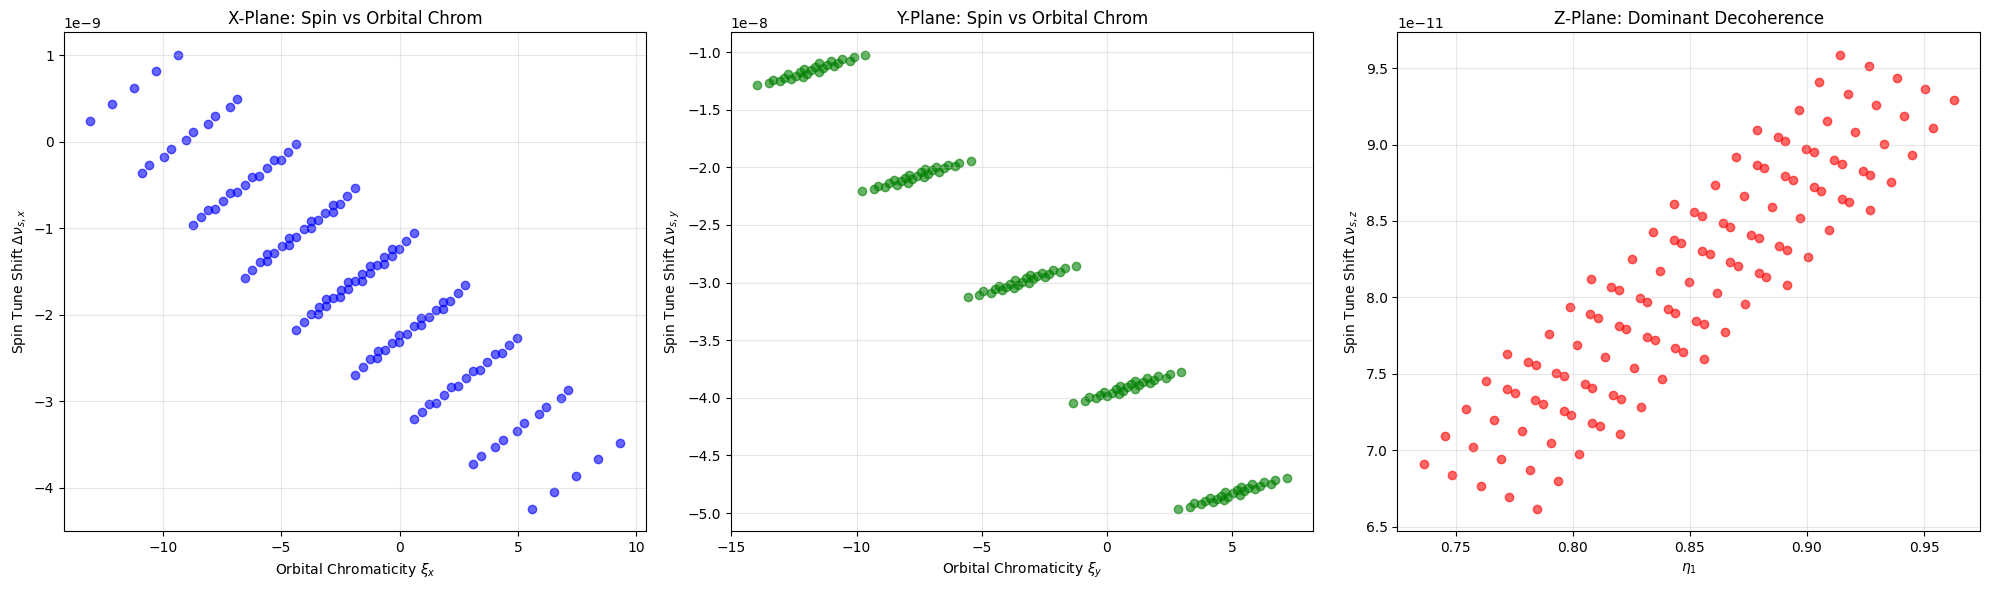

In [21]:
# 1. Извлекаем точное значение SGy1 из нашего найденного идеала
best_sgy_val = best_point['SGy1'] 

# 2. Фильтруем данные (используем небольшой допуск, так как числа с плавающей точкой)
df_slice = df[np.isclose(df['SGy1'], best_sgy_val, atol=1e-5)]

# Если в срез попало слишком мало точек, можно взять весь массив для трендов:
if len(df_slice) < 5:
    df_slice = df

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Дальше ваш код без изменений ---

# 1. Зависимость spin_x от xi_x
axes[0].scatter(df_slice['chrom_x'], df_slice['spin_x'], c='blue', alpha=0.6)
axes[0].set_xlabel(r'Orbital Chromaticity $\xi_x$')
axes[0].set_ylabel(r'Spin Tune Shift $\Delta \nu_{s,x}$')
axes[0].set_title('X-Plane: Spin vs Orbital Chrom')
axes[0].grid(True, alpha=0.3)

# 2. Зависимость spin_y от xi_y
axes[1].scatter(df_slice['chrom_y'], df_slice['spin_y'], c='green', alpha=0.6)
axes[1].set_xlabel(r'Orbital Chromaticity $\xi_y$')
axes[1].set_ylabel(r'Spin Tune Shift $\Delta \nu_{s,y}$')
axes[1].set_title('Y-Plane: Spin vs Orbital Chrom')
axes[1].grid(True, alpha=0.3)

# 3. Зависимость spin_z от eta_1 (Связь с продольной динамикой)
axes[2].scatter(df_slice['eta_1'], df_slice['spin_z'], c='red', alpha=0.6)
axes[2].set_xlabel(r'$\eta_1$')
axes[2].set_ylabel(r'Spin Tune Shift $\Delta \nu_{s,z}$')
axes[2].set_title('Z-Plane: Dominant Decoherence')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

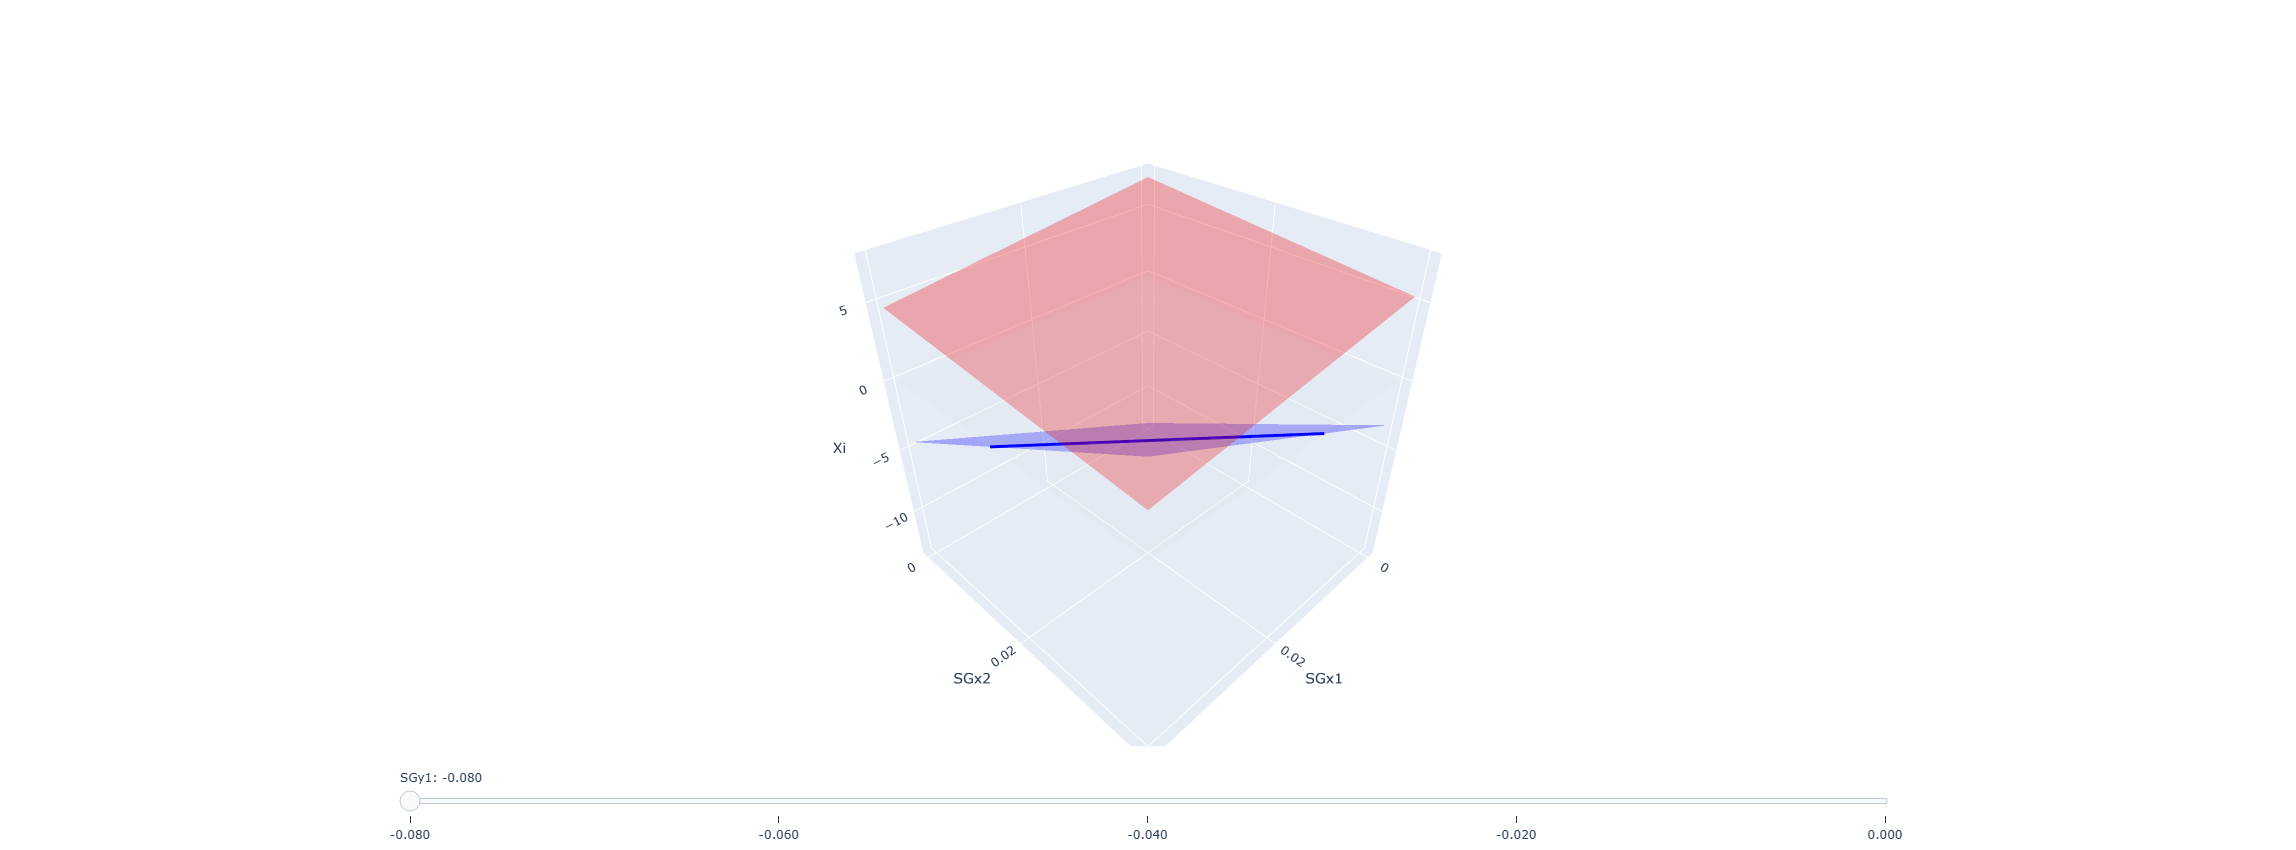

In [22]:
# 1. Подготовка
sgy_values = np.sort(df['SGy1'].unique())
xi_range = np.linspace(df['SGx1'].min(), df['SGx1'].max(), 100)
yi_range = np.linspace(df['SGx2'].min(), df['SGx2'].max(), 100)
X_S, Y_S = np.meshgrid(xi_range, yi_range)

def get_line(X, Y, Z):
    if Z is None or np.all(np.isnan(Z)): return np.array([]), np.array([])
    try:
        cp = plt.contour(X, Y, Z, levels=[0])
        plt.close()
        paths = cp.get_paths()
        if not paths: return np.array([]), np.array([])
        path = max(paths, key=lambda p: len(p.vertices))
        return path.vertices[:, 0], path.vertices[:, 1]
    except:
        return np.array([]), np.array([])

fig = go.Figure()

# Списки для хранения индексов добавленных кадров
valid_sgy = []
traces_per_step = 4

# 2. Генерируем слои
for sgy in sgy_values:
    # Используем небольшую окрестность для надежности фильтрации
    df_s = df[np.isclose(df['SGy1'], sgy, atol=1e-8)]
    
    # Проверка: достаточно ли точек для триангуляции (минимум 4 для linear, больше для cubic)
    if len(df_s) < 10:
        continue
        
    valid_sgy.append(sgy)
    
    # Плоскости
    fig.add_trace(go.Mesh3d(x=df_s['SGx1'], y=df_s['SGx2'], z=df_s['chrom_x'], 
                           color='blue', opacity=0.3, visible=False, name=f'Xi_x_{sgy:.3f}'))
    fig.add_trace(go.Mesh3d(x=df_s['SGx1'], y=df_s['SGx2'], z=df_s['chrom_y'], 
                           color='red', opacity=0.3, visible=False, name=f'Xi_y_{sgy:.3f}'))
    
    # Интерполяция и линии
    try:
        zx = griddata((df_s['SGx1'], df_s['SGx2']), df_s['chrom_x'], (X_S, Y_S), method='linear')
        zy = griddata((df_s['SGx1'], df_s['SGx2']), df_s['chrom_y'], (X_S, Y_S), method='linear')
        lx_x, lx_y = get_line(X_S, Y_S, zx)
        ly_x, ly_y = get_line(X_S, Y_S, zy)
        
        fig.add_trace(go.Scatter3d(x=lx_x, y=lx_y, z=np.zeros_like(lx_x), mode='lines', 
                                   line=dict(color='blue', width=6), visible=False))
        fig.add_trace(go.Scatter3d(x=ly_x, y=ly_y, z=np.zeros_like(ly_x), mode='lines', 
                                   line=dict(color='red', width=6), visible=False))
    except:
        # Если интерполяция все равно упала, добавляем пустые линии, чтобы не сбить индексы ползунка
        fig.add_trace(go.Scatter3d(x=[], y=[], z=[], mode='lines', visible=False))
        fig.add_trace(go.Scatter3d(x=[], y=[], z=[], mode='lines', visible=False))

# 3. Постоянные элементы (Пол и Точка)
fig.add_trace(go.Mesh3d(x=[xi_range.min(), xi_range.max(), xi_range.min(), xi_range.max()],
                       y=[yi_range.min(), yi_range.min(), yi_range.max(), yi_range.max()],
                       z=[0,0,0,0], color='lightgray', opacity=0.1, name='Floor', visible=True))

# 4. Настройка ползунка
steps = []
num_valid = len(valid_sgy)
for i, sgy in enumerate(valid_sgy):
    vis_mask = [False] * (num_valid * traces_per_step) + [True]
    for j in range(traces_per_step):
        vis_mask[i * traces_per_step + j] = True
        
    steps.append(dict(
        method="update", label=f"{sgy:.3f}",
        args=[{"visible": vis_mask}, {"title": f"Geometry at SGy1 = {sgy:.4f}"}]
    ))

# Включаем первый валидный кадр
if num_valid > 0:
    for k in range(traces_per_step): fig.data[k].visible = True

fig.update_layout(
    sliders=[dict(active=0, steps=steps, len=0.7, x=0.15, currentvalue={"prefix": "SGy1: "})],
    scene=dict(xaxis_title='SGx1', yaxis_title='SGx2', zaxis_title=r'Xi'),
    height=850
)
fig.show()

In [23]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import plotly.io as pio

pio.renderers.default = 'notebook'

# 1. Функция извлечения линий (универсальная)
def get_line_coords(X, Y, Z):
    try:
        cp = plt.contour(X, Y, Z, levels=[0])
        plt.close()
        paths = cp.get_paths()
        if not paths: return [None], [None]
        all_x, all_y = [], []
        for path in paths:
            v = path.vertices
            all_x.extend(v[:, 0].tolist() + [None])
            all_y.extend(v[:, 1].tolist() + [None])
        return all_x, all_y
    except:
        return [None], [None]

# 2. Подготовка сетки
xi_range = np.linspace(df['SGx1'].min(), df['SGx1'].max(), 100)
yi_range = np.linspace(df['SGx2'].min(), df['SGx2'].max(), 100)
X_S, Y_S = np.meshgrid(xi_range, yi_range)

# Проредим SGy1, чтобы ползунок был плавным и не перегружал память (каждое 5-е значение)
raw_sgy = np.sort(df['SGy1'].unique())
sgy_values = raw_sgy[::5] if len(raw_sgy) > 15 else raw_sgy

fig = go.Figure()
valid_sgy = []
traces_per_step = 3 

# 3. Генерация кадров
for i, sgy in enumerate(sgy_values):
    # Фильтрация с допуском
    df_s = df[np.isclose(df['SGy1'], sgy, atol=1e-8)]
    if len(df_s) < 10: continue
    
    valid_sgy.append(sgy)
    
    # Интерполяция
    points = df_s[['SGx1', 'SGx2']].values
    zk = griddata(points, df_s['K_total'], (X_S, Y_S), method='linear')
    zx = griddata(points, df_s['chrom_x'], (X_S, Y_S), method='linear')
    zy = griddata(points, df_s['chrom_y'], (X_S, Y_S), method='linear')
    
    # Trace 1: Heatmap
    fig.add_trace(go.Heatmap(
        x=xi_range, y=yi_range, z=zk,
        colorscale='Viridis_r', opacity=0.8,
        showscale=True,
        colorbar=dict(title="K_total", x=1.1, thickness=20),
        visible=False
    ))
    
    # Trace 2 & 3: Линии Xi=0
    lx_x, lx_y = get_line_coords(X_S, Y_S, zx)
    ly_x, ly_y = get_line_coords(X_S, Y_S, zy)
    
    fig.add_trace(go.Scatter(x=lx_x, y=lx_y, mode='lines', line=dict(color='cyan', width=4), name='xi_x=0', visible=False))
    fig.add_trace(go.Scatter(x=ly_x, y=ly_y, mode='lines', line=dict(color='magenta', width=4), name='xi_y=0', visible=False))

# Включаем только первый кадр
if len(fig.data) >= 3:
    for k in range(3): fig.data[k].visible = True

# 4. Настройка ползунка
steps = []
for i, sgy in enumerate(valid_sgy):
    vis_mask = [False] * (len(valid_sgy) * traces_per_step)
    for j in range(traces_per_step):
        vis_mask[i * traces_per_step + j] = True
        
    steps.append(dict(
        method="update",
        label=f"{sgy:.3f}",
        args=[{"visible": vis_mask}, {"title": f"SCT Map | SGy1 = {sgy:.6f}"}]
    ))

fig.update_layout(
    sliders=[dict(active=0, currentvalue={"prefix": "SGy1: "}, pad={"t": 50}, len=0.6, x=0.2, steps=steps)],
    xaxis_title='SGx1', yaxis_title='SGx2',
    width=1000, height=800,
    margin=dict(l=80, r=180, b=120, t=80),
    template='plotly_white'
)

fig.show()

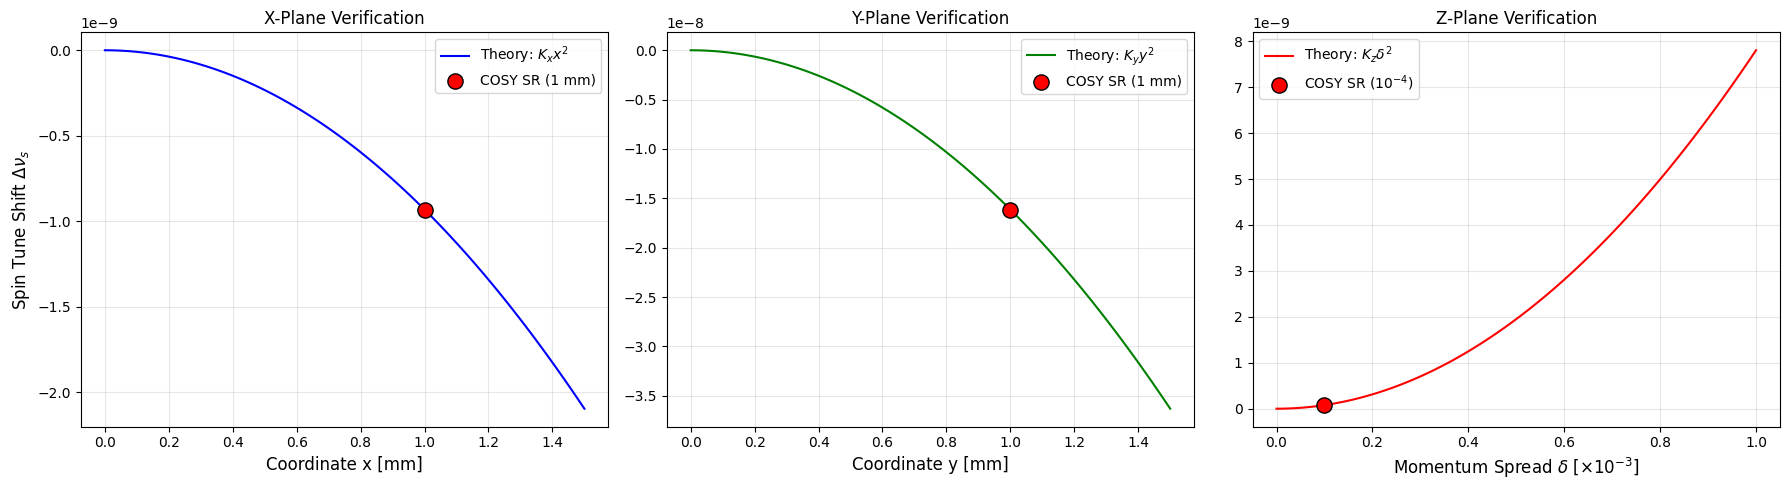

Проверка: для X-частицы теория дает -9.32e-10, COSY дает -9.34e-10


In [24]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Твои реальные параметры из кода COSY
x_test = 1e-3  # 1 мм
y_test = 1e-3  # 1 мм
z_test = 1e-4  # delta (dP/P)

# 2. Коэффициенты K из оптимальной точки
kx, ky, kz = best_point['quad_Kx'], best_point['quad_Ky'], best_point['quad_Kz']

# 3. Построение 3-х графиков верификации
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# --- ОСЬ X (Абсцисса: x [mm], Ордината: Delta spin-tune) ---
x_ax = np.linspace(0, 1.5e-3, 100)
ax1.plot(x_ax * 1000, kx * x_ax**2, 'b-', label=r'Theory: $K_x x^2$')
ax1.scatter(x_test * 1000, best_point['spin_x'], color='red', s=120, 
            edgecolor='black', label='COSY SR (1 mm)', zorder=5)
ax1.set_xlabel('Coordinate x [mm]', fontsize=12)
ax1.set_ylabel(r'Spin Tune Shift $\Delta \nu_s$', fontsize=12)
ax1.set_title(f'X-Plane Verification')

# --- ОСЬ Y (Абсцисса: y [mm]) ---
y_ax = np.linspace(0, 1.5e-3, 100)
ax2.plot(y_ax * 1000, ky * y_ax**2, 'g-', label=r'Theory: $K_y y^2$')
ax2.scatter(y_test * 1000, best_point['spin_y'], color='red', s=120, 
            edgecolor='black', label='COSY SR (1 mm)', zorder=5)
ax2.set_xlabel('Coordinate y [mm]', fontsize=12)
ax2.set_title(f'Y-Plane Verification')

# --- ОСЬ Z (Абсцисса: delta [10^-4]) ---
z_ax = np.linspace(0, 1*1e-3, 100)
ax3.plot(z_ax * 1000, kz * z_ax**2, 'r-', label=r'Theory: $K_z \delta^2$')
ax3.scatter(z_test * 1000, best_point['spin_z'], color='red', s=120, 
            edgecolor='black', label='COSY SR ($10^{-4}$)', zorder=5)
ax3.set_xlabel(r'Momentum Spread $\delta$ [$\times 10^{-3}$]', fontsize=12)
ax3.set_title(f'Z-Plane Verification')

for ax in [ax1, ax2, ax3]:
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Проверка: для X-частицы теория дает {kx * x_test**2:.2e}, COSY дает {best_point['spin_x']:.2e}")

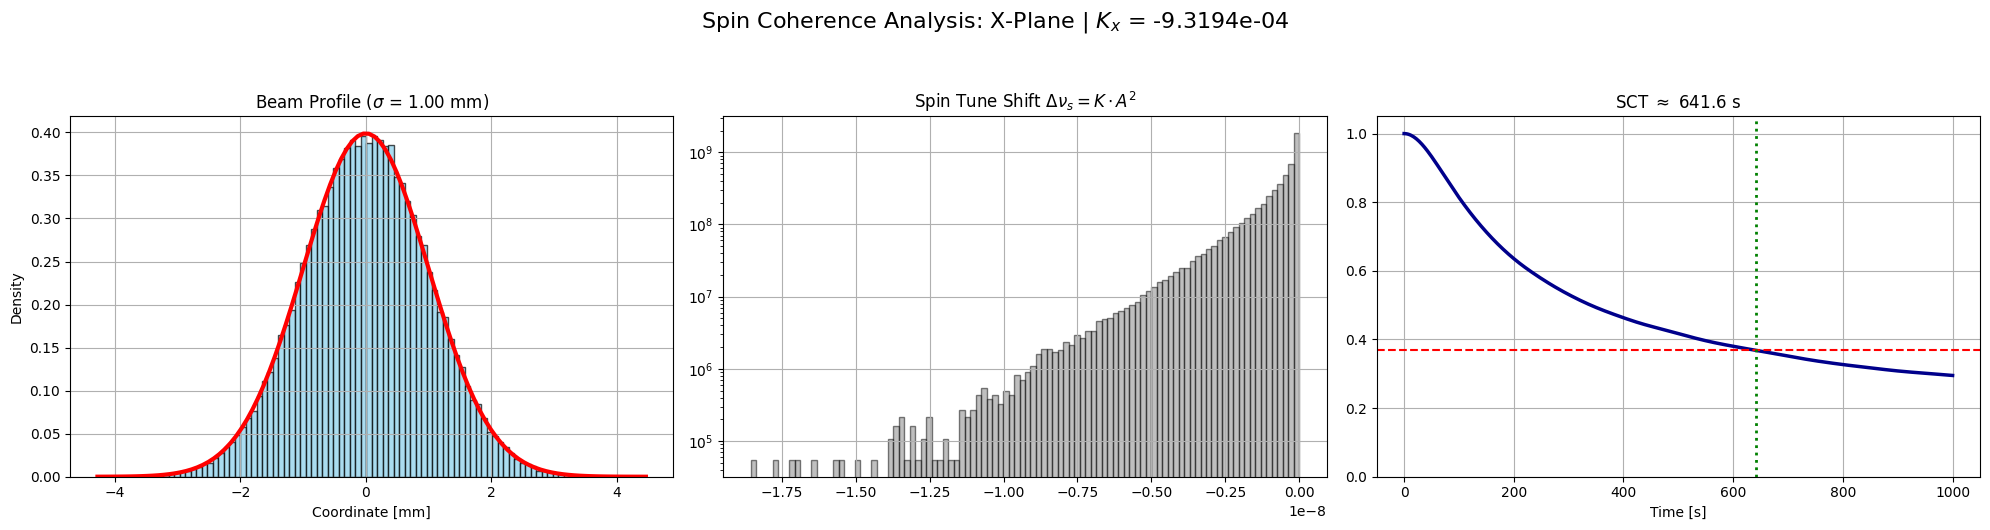

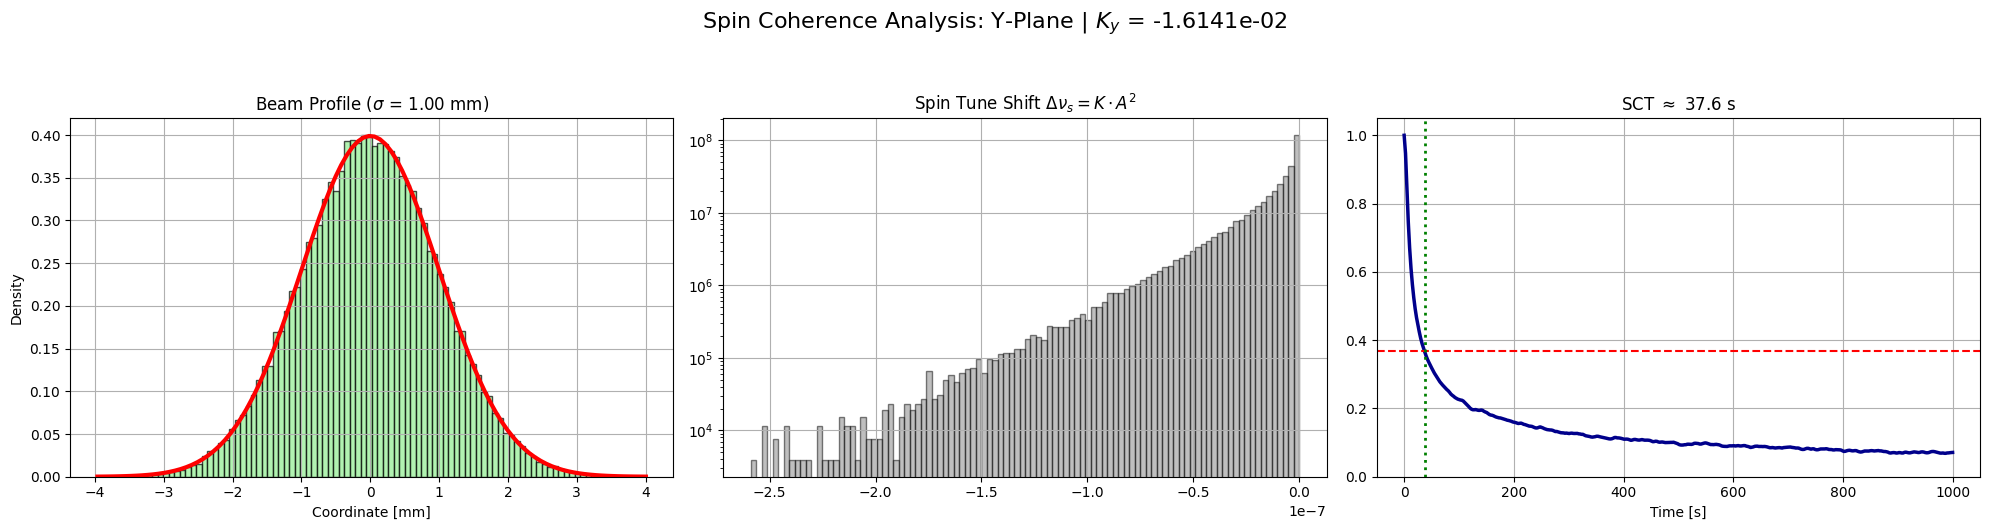

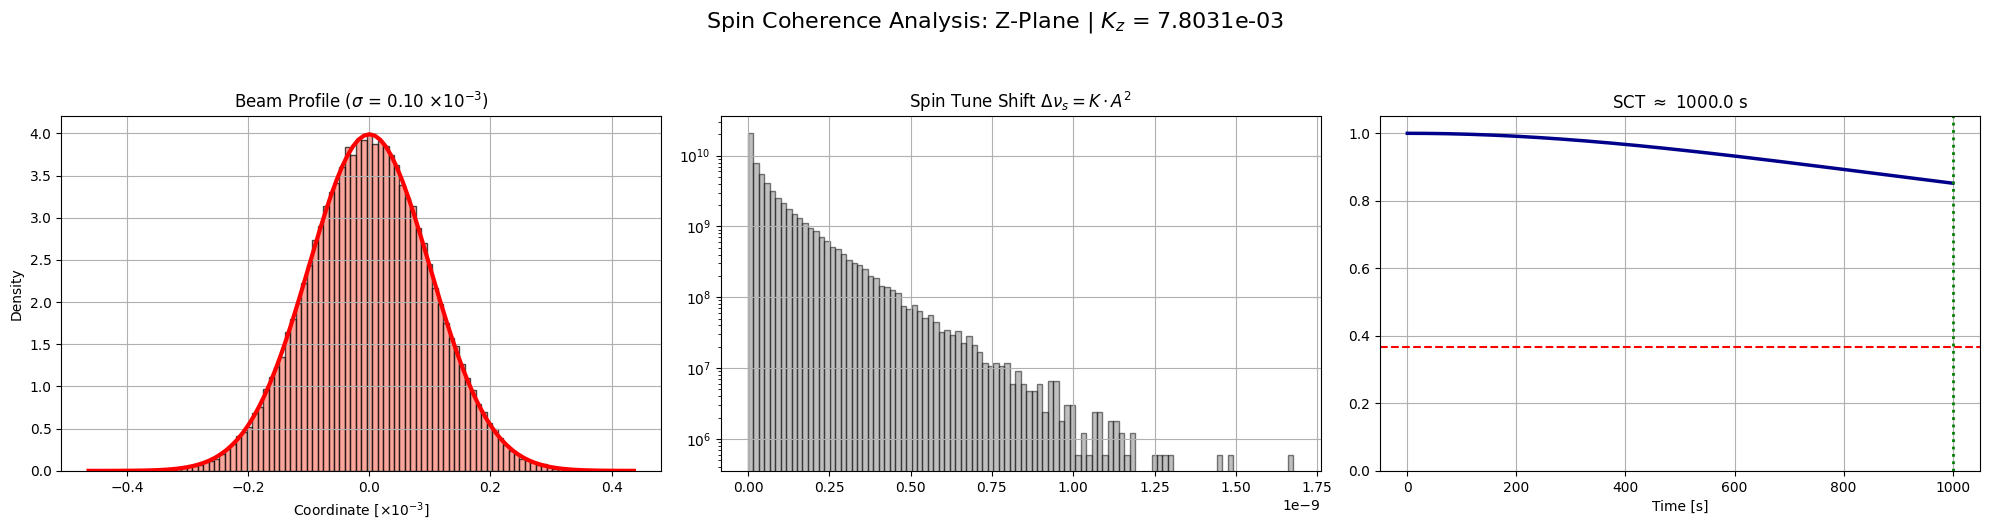

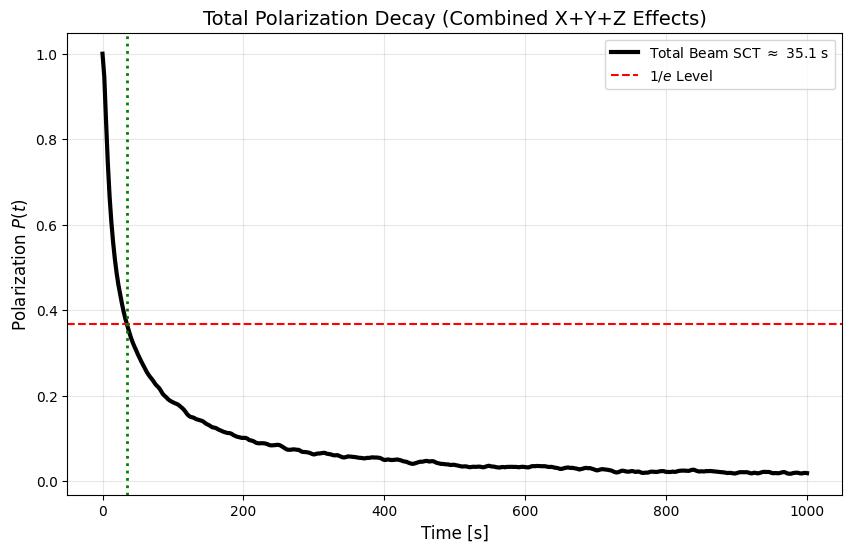

Итоговый результат: SCT = 35.09 секунд


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# --- 1. ГЕНЕРАЦИЯ ЕДИНОГО АНСАМБЛЯ (Один раз на весь расчет) ---
n_particles = 100000
sigma_x, sigma_y, sigma_delta = 0.001, 0.001, 1e-4

# Единый массив координат для всех частиц
ensemble = {
    'X': np.random.normal(0, sigma_x, n_particles),
    'Y': np.random.normal(0, sigma_y, n_particles),
    'Z': np.random.normal(0, sigma_delta, n_particles)
}

# Коэффициенты из вашей лучшей точки
kx, ky, kz = best_point['quad_Kx'], best_point['quad_Ky'], best_point['quad_Kz']

L_ring = 150 # m, Accelerator Length
c = 3e8 # m/s, speed of ligth
gamma = 1.143914
beta = np.sqrt(1-1/(gamma**2));

T_rev = L_ring / (beta * c)
time_axis = np.linspace(0, 1000, 400) 

# Переменная для накопления суммарного сдвига (честная сумма по частицам)
total_d_nu = np.zeros(n_particles)

# Данные для красивой визуализации по осям
axes_config = [
    {'name': 'X', 'coords': ensemble['X'], 'K': kx, 'color': 'skyblue', 'unit': 'mm', 'scale': 1000, 'sig': sigma_x},
    {'name': 'Y', 'coords': ensemble['Y'], 'K': ky, 'color': 'lightgreen', 'unit': 'mm', 'scale': 1000, 'sig': sigma_y},
    {'name': 'Z', 'coords': ensemble['Z'], 'K': kz, 'color': 'salmon', 'unit': r'$\times 10^{-3}$', 'scale': 1000, 'sig': sigma_delta}
]

# --- 2. ЦИКЛ ПО ОСЯМ (Используем координаты из единого ансамбля) ---
for p in axes_config:
    d_nu_axis = p['K'] * p['coords']**2
    total_d_nu += d_nu_axis # Добавляем вклад этой оси к тем же самым частицам
    
    # Расчет затухания P(t) для конкретной оси
    polarization = [np.abs(np.mean(np.exp(1j * 2 * np.pi * d_nu_axis * (t/T_rev)))) for t in time_axis]
    sct_val = time_axis[np.argmin(np.abs(np.array(polarization) - 1/np.e))]

    # ВАШ ЛЮБИМЫЙ ДИЗАЙН
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(fr'Spin Coherence Analysis: {p["name"]}-Plane | $K_{p["name"].lower()}$ = {p["K"]:.4e}', fontsize=16, y=1.05)

    ax1.hist(p['coords'] * p['scale'], 100, density=True, color=p['color'], alpha=0.7, edgecolor='black')
    bins = np.linspace(p['coords'].min()*p['scale'], p['coords'].max()*p['scale'], 100)
    ax1.plot(bins, norm.pdf(bins, 0, p['sig']*p['scale']), linewidth=3, color='red', label='Gaussian Fit')
    ax1.set_title(fr'Beam Profile ($\sigma$ = {p["sig"]*p["scale"]:.2f} {p["unit"]})', fontsize=12)
    ax1.set_xlabel(fr'Coordinate [{p["unit"]}]')
    ax1.set_ylabel('Density')

    ax2.hist(d_nu_axis, 100, density=True, color='gray', alpha=0.5, edgecolor='black')
    ax2.set_title(fr'Spin Tune Shift $\Delta \nu_s = K \cdot A^2$', fontsize=12)
    ax2.set_yscale('log')

    ax3.plot(time_axis, polarization, color='darkblue', linewidth=2.5)
    ax3.axhline(1/np.e, color='red', linestyle='--')
    ax3.axvline(sct_val, color='green', linestyle=':', lw=2)
    ax3.set_title(fr'SCT $\approx$ {sct_val:.1f} s', fontsize=12)
    ax3.set_xlabel('Time [s]')
    ax3.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

# --- 3. ФИНАЛЬНЫЙ СУММАРНЫЙ SCT (Для тех же самых частиц) ---
total_pol = [np.abs(np.mean(np.exp(1j * 2 * np.pi * total_d_nu * (t/T_rev)))) for t in time_axis]
total_sct = time_axis[np.argmin(np.abs(np.array(total_pol) - 1/np.e))]

plt.figure(figsize=(10, 6))
plt.plot(time_axis, total_pol, color='black', linewidth=3, label=fr'Total Beam SCT $\approx$ {total_sct:.1f} s')
plt.axhline(1/np.e, color='red', linestyle='--', label=r'$1/e$ Level')
plt.axvline(total_sct, color='green', linestyle=':', lw=2)
plt.title('Total Polarization Decay (Combined X+Y+Z Effects)', fontsize=14)
plt.xlabel('Time [s]', fontsize=12)
plt.ylabel('Polarization $P(t)$', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Итоговый результат: SCT = {total_sct:.2f} секунд")